# Script for the data quality analysis of EDA data from the Empatica EmbracePlus

A short outline: the first section will first do data wrangling and processing before tackling signal-, index-, and event-level validation. The processing will have to deal with idiosyncratic data structures that are inherent to most data acquistions and we believe that readers can easily skip ahead to the actual validation sections. All important decisions regarding the preprocessing are reported in the main manuscript (to the best of our knowledge). 

## ETL and Preprocessing

Let's start with some loads and style choices 

In [1]:
import pandas as pd
import numpy as np
import datetime as dt
from datetime import timedelta
import neurokit2 as nk
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from pathlib import Path
import re
from scipy import stats
from scipy.stats import wilcoxon, pearsonr, zscore
import statsmodels.formula.api as smf
import matplotlib.transforms as transforms



# suppress all NeuroKit warnings
warnings.filterwarnings(
    "ignore",
    module="neurokit2"
)

#this theme isn't dark at all anymore but we kept the name just out of laziness ;)
DARK_PALETTE = ["#2f6fb0", "#c0392b", "#2e8b45", "#7b4fa0", "#c98a1a", "#2f9e9e"] 

THEME = {
    "figure_bg": "#ffffff",
    "axes_bg": "#ffffff",
    "grid_color": "#ffffff",
    "text_color": "#1f2430",
    "title_color": "#111318",
    "point_color": "#4a4f5a",
    "point_alpha": 0.55,
    "bias_color": "#7b4fa0",
    "theoretical_color": "#2e8b45",
    "loa_color": "#c0392b",
    "annotation_color": "#1f2430",
}

def _style_axis(ax, labelsize = 9):
    ax.set_facecolor(THEME["axes_bg"])
    ax.grid(True, color=THEME["grid_color"], linewidth=0.7, alpha=0.6)
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(colors=THEME["text_color"], labelsize=labelsize)
    ax.xaxis.label.set_color(THEME["text_color"])
    ax.yaxis.label.set_color(THEME["text_color"])

def style_dark_axes(ax, title=None, xlabel=None, ylabel=None, legend_title=None, fontsize = 14):
    """
    Apply the shared light theme (background, grid, spines, fonts) to any
    matplotlib/seaborn Axes -- not just Bland-Altman panels. Use this for
    lineplots, barplots, etc. to keep a consistent look across a report.

    (Function name kept as `style_dark_axes` for compatibility with the
    rest of the notebook, despite the theme now being light.)
    """
    fig = ax.get_figure()
    fig.patch.set_facecolor(THEME["figure_bg"])
    _style_axis(ax)

    if title is not None:
        ax.set_title(title, color=THEME["title_color"], fontsize=fontsize,
                     fontweight="bold", loc="left", family="serif")
    if xlabel is not None:
        ax.set_xlabel(xlabel, fontsize=fontsize - 3, fontweight="bold")
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=fontsize - 3, fontweight="bold")

    legend = ax.get_legend()
    if legend is not None:
        legend.get_frame().set_facecolor(THEME["axes_bg"])
        legend.get_frame().set_edgecolor(THEME["grid_color"])
        for text in legend.get_texts():
            text.set_color(THEME["text_color"])
        if legend_title is not None:
            legend.set_title(legend_title)
        if legend.get_title() is not None:
            legend.get_title().set_color(THEME["text_color"])

    return ax

### Parsing

In [2]:
raw_eda_df = pd.read_csv("EDA_Empatica/eda_all_participants.csv")
raw_eda_df.head()


,participant_id,device_id,timestamp,local_time_sec,unix_timestamp,eda
0,OITC01,3YK671D2Y6,2026-01-26 12:33:50.665465+01:00,12:33:50,1769427230665465,-0.032100
1,OITC01,3YK671D2Y6,2026-01-26 12:33:50.915448+01:00,12:33:50,1769427230915448,-0.029464
2,OITC01,3YK671D2Y6,2026-01-26 12:33:51.165431+01:00,12:33:51,1769427231165431,-0.028338
3,OITC01,3YK671D2Y6,2026-01-26 12:33:51.415414+01:00,12:33:51,1769427231415414,-0.027768
4,OITC01,3YK671D2Y6,2026-01-26 12:33:51.665397+01:00,12:33:51,1769427231665397,-0.028922


In [3]:
# ============================================================
# SETTINGS
# ============================================================

# Folder containing all txt files
DATA_DIR = Path(r"EDA_Reference")

# Timezone
TIMEZONE = "Europe/Berlin"


# ============================================================
# HELPER FUNCTIONS
# ============================================================

def extract_metadata(lines):
    """
    Extract metadata from header.
    """

    metadata = {}

    for line in lines:

        # participant id comes from filename later

        if "Sitzungsdatum:" in line:

            match = re.search(
                r"Sitzungsdatum:\s*([0-9\.]+)\s*Sitzungszeit:\s*([0-9:]+)",
                line
            )

            if match:
                metadata["session_date"] = match.group(1)
                metadata["session_time"] = match.group(2)

        if "Endzeit:" in line:

            match = re.search(
                r"Endzeit:\s*([0-9:\.]+)",
                line
            )

            if match:
                metadata["duration"] = match.group(1)

    return metadata


def find_data_start(lines):
    """
    Find the first actual numeric data row.
    """

    for i, line in enumerate(lines):

        # numeric rows begin like:
        # 0.00390625000,7.388

        if re.match(r"^\d+\.\d+,\-?\d+\.?\d*", line.strip()):
            return i

    return None


# ============================================================
# MAIN PARSER
# ============================================================

all_dfs = []

txt_files = list(DATA_DIR.glob("*.txt"))

print(f"Found {len(txt_files)} txt files")


for file_path in txt_files:

    print(f"Processing: {file_path.name}")

    # --------------------------------------------------------
    # Participant ID from filename
    # --------------------------------------------------------

    participant_id = file_path.stem.upper()

    # --------------------------------------------------------
    # Read file
    # --------------------------------------------------------

    with open(file_path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    # --------------------------------------------------------
    # Extract metadata
    # --------------------------------------------------------

    metadata = extract_metadata(lines)

    session_date = metadata["session_date"]
    session_time = metadata["session_time"]
    duration = metadata["duration"]

    # --------------------------------------------------------
    # Construct absolute end timestamp
    # --------------------------------------------------------

    end_timestamp = pd.Timestamp(
        f"{session_date} {session_time}",
        tz=TIMEZONE
    )

    # German dates are DD.MM.YYYY
    end_timestamp = pd.to_datetime(
        end_timestamp,
        dayfirst=True
    )

    duration_td = pd.to_timedelta(duration)

    # recording start timestamp
    start_timestamp = end_timestamp - duration_td

    # --------------------------------------------------------
    # Locate numeric data
    # --------------------------------------------------------

    data_start_idx = find_data_start(lines)

    if data_start_idx is None:
        print(f"  -> No data found in {file_path.name}")
        continue

    # --------------------------------------------------------
    # Parse numeric section
    # --------------------------------------------------------

    data_lines = lines[data_start_idx:]

    # convert into dataframe
    temp_df = pd.read_csv(
        pd.io.common.StringIO("".join(data_lines)),
        header=None,
        names=["elapsed_sec", "eda"]
    )

    # --------------------------------------------------------
    # Construct timestamps
    # --------------------------------------------------------

    temp_df["timestamp"] = (
        start_timestamp +
        pd.to_timedelta(temp_df["elapsed_sec"], unit="s")
    )

    # --------------------------------------------------------
    # Additional columns
    # --------------------------------------------------------

    temp_df["participant_id"] = participant_id

    # --------------------------------------------------------
    # Final column order
    # --------------------------------------------------------

    filtered = nk.signal_filter(
        temp_df["eda"].values,
        sampling_rate=256,
        lowcut=None,
        highcut=1.5,   #despiking filter (e.g. Hossain et al., 2022)
        method="butterworth",
        order=8
    )

        # Properly resample signal to make it comparable to Embrace
    eda_4hz = nk.signal_resample(
        filtered,
        sampling_rate=256,
        desired_sampling_rate=4,
        method="poly"
    )

    # recompute timestamps from original timeline
    start_time = temp_df["timestamp"].iloc[0]

    timestamp_4hz = pd.date_range(
        start=start_time,
        periods=len(eda_4hz),
        freq="250ms"
    )

    min_len = min(len(timestamp_4hz), len(eda_4hz))

    temp_df_4hz = pd.DataFrame({
        "participant_id": participant_id,
        "timestamp": timestamp_4hz,
        "eda": eda_4hz
    })
    
    all_dfs.append(temp_df_4hz)

    print(f"  -> Parsed {len(temp_df)} rows")


# ============================================================
# COMBINE ALL FILES
# ============================================================

infiniti_eda_df = pd.concat(
    all_dfs,
    ignore_index=True
)


print("\nFinished.")
print(infiniti_eda_df.head())

print(f"\nTotal rows: {len(infiniti_eda_df):,}")
print(f"Participants: {infiniti_eda_df['participant_id'].nunique()}")

Found 6 txt files
Processing: OITC39.txt
  -> Parsed 632032 rows
Processing: OITC40.txt
  -> Parsed 439040 rows
Processing: OITC44.txt
  -> Parsed 882112 rows
Processing: OITC45.txt
  -> Parsed 300736 rows
Processing: OITC46.txt
  -> Parsed 401984 rows
Processing: OITC50.txt
  -> Parsed 803536 rows

Finished.
  participant_id                           timestamp       eda
0         OITC39 2026-03-21 14:26:44.128906250+01:00  3.752010
1         OITC39 2026-03-21 14:26:44.378906250+01:00  8.029967
2         OITC39 2026-03-21 14:26:44.628906250+01:00  7.042441
3         OITC39 2026-03-21 14:26:44.878906250+01:00  7.545247
4         OITC39 2026-03-21 14:26:45.128906250+01:00  7.191382

Total rows: 54,054
Participants: 6


### Timestamps and Self-Report 

In [4]:
tstamps_df = pd.read_excel("Supplementary_Inputs/Timestamps.xlsx")
tstamps_df.head()


,ID,Session,Station,Color,Start_Baseline,End_Baseline,End_Trail1,End_Trail2,End_Trail3,Start_Drone,End_Drone,Time_Trial,Group,Type,Trial_1,Trial_2,Trial_3,Progress_Drone,Notes
0,OITC01,2601_1,1.0,Blau,13:59:00,14:04:00,NaN,NaN,NaN,14:50:00,15:20:00,900,Control,OITC,Control,Control,Control,3.0,NaN
1,OITC02,2601_1,2.0,Gelb,13:59:00,14:04:00,NaN,NaN,NaN,14:50:00,15:20:00,900,Control,OITC,Control,Control,Control,4.0,NaN
2,OITC03,2601_1,3.0,Grün,13:59:00,14:04:00,14:30:00,14:36:00,14:41:00,14:50:00,15:20:00,300,1-Back,OITC,100,100,100,4.0,NaN
3,OITC04,2601_1,4.0,Orange,13:59:00,14:04:00,NaN,NaN,NaN,14:50:00,15:20:00,300,1-Back,OITC,NaN,NaN,NA,3.0,"Did not behave according to instructions, did ..."
4,OITC05,2601_1,5.0,Pink,13:59:00,14:04:00,14:27:00,14:32:00,14:37:00,14:50:00,15:20:00,300,Dual-2-Back,OITC,46.5,53.75,62.34,5.0,NaN


In [5]:

questionnaire_df = pd.read_excel("Supplementary_Inputs/Fatigue_1.xlsx")
questionnaire_df.head()

,CASE,SERIAL,REF,QUESTNNR,MODE,STARTED,AR1,EM,IN06_01,IN06_02,...,MAILSENT,LASTDATA,STATUS,FINISHED,Q_VIEWER,LASTPAGE,MAXPAGE,MISSING,MISSREL,TIME_RSI
0,Interview-Nummer (fortlaufend),Personenkennung oder Teilnahmecode (sofern ver...,Referenz (sofern im Link angegeben),"Fragebogen, der im Interview verwendet wurde",Interview-Modus,Zeitpunkt zu dem das Interview begonnen hat (E...,Arousal: Wie aktiviert hast du dich während de...,ES,ID + More: Person-ID,ID + More: Farbe,...,Versandzeitpunkt der Einladungsmail (nur für n...,Zeitpunkt als der Datensatz das letzte mal geä...,Status des Interviews (Markierung),Wurde die Befragung abgeschlossen (letzte Seit...,Hat der Teilnehmer den Fragebogen nur angesehe...,"Seite, die der Teilnehmer zuletzt bearbeitet hat","Letzte Seite, die im Fragebogen bearbeitet wurde",Anteil fehlender Antworten in Prozent,Anteil fehlender Antworten (gewichtet nach Rel...,Ausfüll-Geschwindigkeit (relativ)
1,34,NaN,NaN,Fatigue,interview,2026-01-26 14:35:51,4,1,OITC01,Blau,...,NaN,2026-01-26 14:40:17,complete,1,0,7,7,0,0,0.93
2,35,NaN,NaN,Fatigue,interview,2026-01-26 14:36:04,9,4,OITC02,Gelb,...,NaN,2026-01-26 14:41:14,complete,1,0,7,7,0,0,0.79
3,36,NaN,NaN,Fatigue,interview,2026-01-26 14:38:38,2,2,OITC04,orange,...,NaN,2026-01-26 14:41:06,complete,1,0,7,7,0,0,1.78
4,37,NaN,NaN,Fatigue,interview,2026-01-26 14:38:50,8,4,OITC05,Pink,...,NaN,2026-01-26 14:40:49,complete,1,0,7,7,0,0,2.36


### Segmentation and Data Harmonization

In [6]:
def process_eda_segment(eda_values): # despiking as before
    filtered = nk.signal_filter(
        eda_values,
        sampling_rate=4,
        lowcut=None,
        highcut=1.5,
        method="butterworth",
        order=8
    )
    return np.round(filtered, 4)

def segment_eda_by_trials(raw_eda_df, tstamps_df, questionnaire_df):
    """
    Segment EDA data into trial periods for each participant based on condition.
    
    Parameters:
    -----------
    raw_eda_df : DataFrame with columns [participant_id, timestamp, eda]
    tstamps_df : DataFrame with trial timestamps
    questionnaire_df : DataFrame with questionnaire data (for Control condition)
    
    Returns:
    --------
    DataFrame in wide format with one row per participant and EDA segments in cells
    """
    
    # Convert timestamp to datetime with proper timezone handling
    raw_eda_df = raw_eda_df.copy()
    
    # Handle both string and already-datetime timestamps
    if not pd.api.types.is_datetime64_any_dtype(raw_eda_df['timestamp']):
        raw_eda_df['timestamp'] = pd.to_datetime(raw_eda_df['timestamp'], utc=True, format="mixed")
    
    # Ensure timezone awareness
    raw_eda_df['timestamp'] = raw_eda_df['timestamp'].dt.tz_convert('Europe/Berlin')
    
    # Results storage
    results = []
    
    # Get unique participants from raw EDA data
    participants = raw_eda_df['participant_id'].unique()
    
    for participant in participants:
        # Get participant's raw EDA data
        participant_eda = raw_eda_df[raw_eda_df['participant_id'] == participant].copy()
        participant_eda = participant_eda.sort_values('timestamp').reset_index(drop=True)
        
        # Get participant metadata
        meta_row = tstamps_df[tstamps_df['ID'] == participant]
        
        if meta_row.empty:
            print(f"Warning: No metadata found for participant {participant}")
            continue
        
        meta = meta_row.iloc[0]
        condition = meta['Group']
         
        wrong_date_participants = {
    'OITC14', 'OITC15', 'OITC16',
    'OITC17', 'OITC18', 'OITC19', 'OITC20'
        }

        if participant in wrong_date_participants:
            session_date = "2026-01-30"
        else:
            session_date = participant_eda['timestamp'].dt.date.iloc[0]
        
        # Initialize row dictionary
        row = {'participant_id': participant, 'condition': condition}
        
        # ========== DRONE SEGMENT ==========
        try:
            start_drone_str = meta['Start_Drone']
            end_drone_str = meta['End_Drone']
            
            # Skip if missing
            if pd.isna(start_drone_str) or pd.isna(end_drone_str):
                row['Drone'] = np.nan
            else:
                start_drone = pd.to_datetime(
                    f"{session_date} {start_drone_str}", 
                    format='%Y-%m-%d %H:%M:%S'
                )
                end_drone = pd.to_datetime(
                    f"{session_date} {end_drone_str}", 
                    format='%Y-%m-%d %H:%M:%S'
                )
                
                # Make timezone-aware to match raw data
                start_drone = start_drone.tz_localize('Europe/Berlin')
                end_drone = end_drone.tz_localize('Europe/Berlin')
                
                drone_data = participant_eda[
                    (participant_eda['timestamp'] >= start_drone) & 
                    (participant_eda['timestamp'] <= end_drone)
                ]['eda'].values
                
                drone_segment = process_eda_segment(drone_data) if len(drone_data) > 0 else np.array([])
                
                row['Drone'] = drone_segment if len(drone_segment) > 0 else np.nan
                row['Drone_start_timestamp'] = start_drone
                row['Drone_end_timestamp'] = end_drone
            
        except Exception as e:
            print(f"Error processing Drone segment for {participant}: {e}")
            row['Drone'] = np.nan

        # ============== BASELINE SEGMENT =================
        try:
            start_base_str = meta['Start_Baseline']
            end_base_str = meta['End_Baseline']

            if pd.isna(start_base_str) or pd.isna(end_base_str):
                row['Baseline'] = np.nan
            else:
                start_base = pd.to_datetime(f"{session_date} {start_base_str}", format='%Y-%m-%d %H:%M:%S')
                end_base = pd.to_datetime(f"{session_date} {end_base_str}", format='%Y-%m-%d %H:%M:%S')

                start_base = start_base.tz_localize('Europe/Berlin')
                end_base = end_base.tz_localize('Europe/Berlin')

                baseline_data = participant_eda[
                    (participant_eda['timestamp'] >= start_base) &
                    (participant_eda['timestamp'] <= end_base)
                ]['eda'].values
                baseline_segment = process_eda_segment(baseline_data) if len(baseline_data) > 0 else np.array([])
                row['Baseline'] = baseline_segment if len(baseline_segment) > 0 else np.nan
                row['Baseline_start_timestamp'] = start_base
                row['Baseline_end_timestamp'] = end_base

        except Exception as e:
            print(f"Error processing Baseline segment for {participant}: {e}")
            row['Baseline'] = np.nan
        
        # ========== TRIAL SEGMENTS ==========
        if participant == 'OITC45' or participant == 'OITC46':
            print(f"  Special case: OITC45 and OITC46 - using last three 5-minute segments from recording")

            # Safety check: must have data
            if participant_eda is None or participant_eda.empty:
                print("Warning: OITC45 has no EDA data.")
                for i in range(1, 4):
                    row[f'Trial_{i}'] = np.nan
                    row[f'Trial_{i}_start_timestamp'] = np.nan
                    row[f'Trial_{i}_end_timestamp'] = np.nan
                row['All_Trials'] = np.nan
                results.append(row)
                continue

            participant_eda = participant_eda.sort_values('timestamp').reset_index(drop=True)

            # Use last timestamp as anchor
            last_ts = participant_eda['timestamp'].iloc[-1]

            # Build clean 5-min windows (no cascading errors)
            trial_times = []
            for i in range(3, 0, -1):
                end = last_ts - timedelta(minutes=5 * (i - 1))
                start = end - timedelta(minutes=5)
                trial_times.append((start, end))

        elif condition == 'Control':
            # Get STARTED timestamp from questionnaire (end of all three trials)
            quest_row = questionnaire_df[questionnaire_df['IN06_01'] == participant]
            
            if quest_row.empty:
                print(f"Warning: No questionnaire data for Control participant {participant}")
                for i in range(1, 4):
                    row[f'Trial_{i}'] = np.nan
                row['All_Trials'] = np.nan
                results.append(row)
                continue
            
            started_str = quest_row.iloc[0]['STARTED']
            
            if pd.isna(started_str):
                print(f"Warning: No STARTED timestamp for Control participant {participant}")
                for i in range(1, 4):
                    row[f'Trial_{i}'] = np.nan
                row['All_Trials'] = np.nan
                results.append(row)
                continue
            
            started_timestamp = pd.to_datetime(started_str)
            
            # Make timezone-aware
            if started_timestamp.tz is None:
                started_timestamp = started_timestamp.tz_localize('Europe/Berlin')
            
            # Three sequential 5-minute segments before STARTED time
            trial_end_3 = started_timestamp
            trial_end_2 = trial_end_3 - timedelta(minutes=5)
            trial_end_1 = trial_end_2 - timedelta(minutes=5)
            
            trial_start_1 = trial_end_1 - timedelta(minutes=5)
            trial_start_2 = trial_end_2 - timedelta(minutes=5)
            trial_start_3 = trial_end_3 - timedelta(minutes=5)
            
            trial_times = [
                (trial_start_1, trial_end_1),
                (trial_start_2, trial_end_2),
                (trial_start_3, trial_end_3)
            ]
        elif condition == 'OITC45_SPECIAL':
            pass  # already handled above  

        else:  # 1-Back or Dual-2-Back
            # Get trial end times (note the typo in column names: "End_Trail" not "End_Trial")
            try:
                trial_end_1_str = meta['End_Trail1']
                trial_end_2_str = meta['End_Trail2']
                trial_end_3_str = meta['End_Trail3']
                
                # Skip if any are missing
                if pd.isna(trial_end_1_str) or pd.isna(trial_end_2_str) or pd.isna(trial_end_3_str):
                    print(f"Warning: Missing trial timestamps for {participant}")
                    for i in range(1, 4):
                        row[f'Trial_{i}'] = np.nan
                    row['All_Trials'] = np.nan
                    results.append(row)
                    continue
                
                trial_end_1 = pd.to_datetime(
                    f"{session_date} {trial_end_1_str}", 
                    format='%Y-%m-%d %H:%M:%S'
                )
                trial_end_2 = pd.to_datetime(
                    f"{session_date} {trial_end_2_str}", 
                    format='%Y-%m-%d %H:%M:%S'
                )
                trial_end_3 = pd.to_datetime(
                    f"{session_date} {trial_end_3_str}", 
                    format='%Y-%m-%d %H:%M:%S'
                )
                
                # Make timezone-aware
                trial_end_1 = trial_end_1.tz_localize('Europe/Berlin')
                trial_end_2 = trial_end_2.tz_localize('Europe/Berlin')
                trial_end_3 = trial_end_3.tz_localize('Europe/Berlin')
                
                trial_start_1 = trial_end_1 - timedelta(minutes=5)
                trial_start_2 = trial_end_2 - timedelta(minutes=5)
                trial_start_3 = trial_end_3 - timedelta(minutes=5)
                
                trial_times = [
                    (trial_start_1, trial_end_1),
                    (trial_start_2, trial_end_2),
                    (trial_start_3, trial_end_3)
                ]
                
            except Exception as e:
                print(f"Error processing trial times for {participant}: {e}")
                for i in range(1, 4):
                    row[f'Trial_{i}'] = np.nan
                row['All_Trials'] = np.nan
                results.append(row)
                continue
        
        # Extract individual trial segments
        all_trial_data = []
        all_trial_timestamps = []
        
        for i, (trial_start, trial_end) in enumerate(trial_times, 1):
            trial_segment = participant_eda[
                (participant_eda['timestamp'] >= trial_start) & 
                (participant_eda['timestamp'] <= trial_end)
            ].copy()
            
            if len(trial_segment) > 0:
                row[f'Trial_{i}'] = process_eda_segment(trial_segment['eda'].values)
                row[f'Trial_{i}_start_timestamp'] = trial_segment['timestamp'].iloc[0]
                row[f'Trial_{i}_end_timestamp'] = trial_segment['timestamp'].iloc[-1]
                all_trial_data.append(process_eda_segment(trial_segment['eda'].values))
                all_trial_timestamps.extend(trial_segment['timestamp'].values)
            else:
                row[f'Trial_{i}'] = np.nan
                row[f'Trial_{i}_start_timestamp'] = np.nan
                row[f'Trial_{i}_end_timestamp'] = np.nan
        
        # Combine all trials
        if all_trial_data:
            combined_trials = np.concatenate(all_trial_data, axis=0)
            row['All_Trials'] = combined_trials
            row['All_Trials_start_timestamp'] = min(all_trial_timestamps)
            row['All_Trials_end_timestamp'] = max(all_trial_timestamps)
        else:
            row['All_Trials'] = np.nan
            row['All_Trials_start_timestamp'] = np.nan
            row['All_Trials_end_timestamp'] = np.nan
        
        results.append(row)
    
    # Create output DataFrame
    output_df = pd.DataFrame(results)
    
    return output_df

# Usage:
segmented_df = segment_eda_by_trials(raw_eda_df, tstamps_df, questionnaire_df)
segmented_df = segmented_df[segmented_df['participant_id'] != 'OITC04'] 
segmented_df.head()  


  Special case: OITC45 and OITC46 - using last three 5-minute segments from recording
  Special case: OITC45 and OITC46 - using last three 5-minute segments from recording


,participant_id,condition,Drone,Drone_start_timestamp,Drone_end_timestamp,Baseline,Baseline_start_timestamp,Baseline_end_timestamp,Trial_1,Trial_1_start_timestamp,Trial_1_end_timestamp,Trial_2,Trial_2_start_timestamp,Trial_2_end_timestamp,Trial_3,Trial_3_start_timestamp,Trial_3_end_timestamp,All_Trials,All_Trials_start_timestamp,All_Trials_end_timestamp
0,OITC01,Control,"[0.2082, 0.2086, 0.2203, 0.217, 0.2056, 0.2066...",2026-01-26 14:50:00+01:00,2026-01-26 15:20:00+01:00,"[0.3014, 0.2298, 0.2237, 0.2305, 0.2262, 0.228...",2026-01-26 13:59:00+01:00,2026-01-26 14:04:00+01:00,"[0.2858, 0.285, 0.2854, 0.285, 0.2847, 0.2848,...",2026-01-26 14:20:51.068724+01:00,2026-01-26 14:25:50.818724+01:00,"[0.1433, 0.1437, 0.1434, 0.1432, 0.1436, 0.143...",2026-01-26 14:25:51.068724+01:00,2026-01-26 14:30:50.818724+01:00,"[0.0819, 0.0812, 0.0826, 0.0818, 0.0804, 0.081...",2026-01-26 14:30:51.068724+01:00,2026-01-26 14:35:50.818641+01:00,"[0.2858, 0.285, 0.2854, 0.285, 0.2847, 0.2848,...",2026-01-26 13:20:51.068724,2026-01-26 13:35:50.818641
1,OITC02,Control,"[0.996, 0.9921, 0.9906, 0.9919, 0.9919, 0.9902...",2026-01-26 14:50:00+01:00,2026-01-26 15:20:00+01:00,"[2.1392, 2.1425, 2.1469, 2.1518, 2.1561, 2.157...",2026-01-26 13:59:00+01:00,2026-01-26 14:04:00+01:00,"[1.5057, 1.5038, 1.5019, 1.4984, 1.4946, 1.492...",2026-01-26 14:21:04.067954+01:00,2026-01-26 14:26:03.817972+01:00,"[0.9609, 0.9615, 0.9618, 0.9615, 0.962, 0.9625...",2026-01-26 14:26:04.067972+01:00,2026-01-26 14:31:03.817990+01:00,"[1.0151, 1.0139, 1.013, 1.0135, 1.0131, 1.0112...",2026-01-26 14:31:04.067990+01:00,2026-01-26 14:36:03.818008+01:00,"[1.5057, 1.5038, 1.5019, 1.4984, 1.4946, 1.492...",2026-01-26 13:21:04.067954,2026-01-26 13:36:03.818008
2,OITC03,1-Back,"[0.0424, 0.0409, 0.0428, 0.0418, 0.0402, 0.041...",2026-01-26 14:50:00+01:00,2026-01-26 15:20:00+01:00,"[0.0396, 0.041, 0.0448, 0.0469, 0.0473, 0.0487...",2026-01-26 13:59:00+01:00,2026-01-26 14:04:00+01:00,"[0.0145, 0.0148, 0.0143, 0.0145, 0.0156, 0.016...",2026-01-26 14:25:31.633013+01:00,2026-01-26 14:29:12.720063+01:00,"[0.0482, 0.0533, 0.0553, 0.0537, 0.053, 0.0539...",2026-01-26 14:31:24.625231+01:00,2026-01-26 14:35:06.747437+01:00,"[0.0336, 0.0342, 0.0341, 0.0335, 0.0334, 0.033...",2026-01-26 14:36:07.688372+01:00,2026-01-26 14:40:59.760526+01:00,"[0.0145, 0.0148, 0.0143, 0.0145, 0.0156, 0.016...",2026-01-26 13:25:31.633013,2026-01-26 13:40:59.760526
4,OITC05,Dual-2-Back,"[0.1201, 0.1229, 0.1246, 0.1246, 0.1239, 0.122...",2026-01-26 14:50:00+01:00,2026-01-26 15:20:00+01:00,"[-0.0028, -0.0045, -0.0045, -0.0041, -0.0041, ...",2026-01-26 13:59:00+01:00,2026-01-26 14:04:00+01:00,"[0.1231, 0.1232, 0.1233, 0.1229, 0.123, 0.1247...",2026-01-26 14:22:00.126603+01:00,2026-01-26 14:26:59.876603+01:00,"[0.0946, 0.0947, 0.0945, 0.0947, 0.0951, 0.094...",2026-01-26 14:27:00.126603+01:00,2026-01-26 14:31:59.876643+01:00,"[0.1046, 0.1039, 0.1033, 0.1035, 0.1045, 0.104...",2026-01-26 14:32:00.126643+01:00,2026-01-26 14:36:59.876660+01:00,"[0.1231, 0.1232, 0.1233, 0.1229, 0.123, 0.1247...",2026-01-26 13:22:00.126603,2026-01-26 13:36:59.876660
5,OITC06,Dual-2-Back,"[0.3845, 0.383, 0.381, 0.3812, 0.3825, 0.3825,...",2026-01-26 14:50:00+01:00,2026-01-26 15:20:00+01:00,"[0.8431, 0.8422, 0.8413, 0.8418, 0.8412, 0.839...",2026-01-26 13:59:00+01:00,2026-01-26 14:04:00+01:00,"[0.6677, 0.667, 0.6698, 0.6743, 0.6779, 0.6822...",2026-01-26 14:22:00.155442+01:00,2026-01-26 14:26:59.905085+01:00,"[0.4905, 0.4921, 0.4903, 0.49, 0.4906, 0.4891,...",2026-01-26 14:28:00.155013+01:00,2026-01-26 14:32:59.904656+01:00,"[0.4113, 0.4118, 0.4112, 0.4108, 0.4113, 0.410...",2026-01-26 14:34:00.154584+01:00,2026-01-26 14:38:59.904387+01:00,"[0.6677, 0.667, 0.6698, 0.6743, 0.6779, 0.6822...",2026-01-26 13:22:00.155442,2026-01-26 13:38:59.904387


In [7]:
segmented_df_inf = segment_eda_by_trials(infiniti_eda_df, tstamps_df, questionnaire_df)
segmented_df_inf.loc[
    segmented_df_inf['participant_id'] == 'OITC44',
    'Drone'
] = np.nan #some seconds of recording overlap that we set to nan manuallly
segmented_df_inf.head()

  Special case: OITC45 and OITC46 - using last three 5-minute segments from recording
  Special case: OITC45 and OITC46 - using last three 5-minute segments from recording


,participant_id,condition,Drone,Drone_start_timestamp,Drone_end_timestamp,Baseline,Baseline_start_timestamp,Baseline_end_timestamp,Trial_1,Trial_1_start_timestamp,Trial_1_end_timestamp,Trial_2,Trial_2_start_timestamp,Trial_2_end_timestamp,Trial_3,Trial_3_start_timestamp,Trial_3_end_timestamp,All_Trials,All_Trials_start_timestamp,All_Trials_end_timestamp
0,OITC39,Control,NaN,2026-03-21 15:11:00+01:00,2026-03-21 15:41:00+01:00,"[6.6803, 6.6756, 6.6709, 6.6667, 6.6614, 6.653...",2026-03-21 14:27:00+01:00,2026-03-21 14:32:00+01:00,"[7.8232, 7.8175, 7.8121, 7.8067, 7.8017, 7.797...",2026-03-21 14:40:27.128906250+01:00,2026-03-21 14:45:26.878906250+01:00,"[8.1532, 8.1485, 8.1429, 8.136, 8.1265, 8.1152...",2026-03-21 14:45:27.128906250+01:00,2026-03-21 14:50:26.878906250+01:00,"[7.9643, 7.9986, 8.0405, 8.0841, 8.1207, 8.147...",2026-03-21 14:50:27.128906250+01:00,2026-03-21 14:55:26.878906250+01:00,"[7.8232, 7.8175, 7.8121, 7.8067, 7.8017, 7.797...",2026-03-21 13:40:27.128906250,2026-03-21 13:55:26.878906250
1,OITC40,Dual-2-Back,NaN,NaT,NaT,"[4.9514, 4.948, 4.9455, 4.9429, 4.9393, 4.9349...",2026-03-21 13:52:30+01:00,2026-03-21 13:57:30+01:00,"[6.2011, 6.2016, 6.2016, 6.2012, 6.1992, 6.196...",2026-03-21 14:02:15.003906250+01:00,2026-03-21 14:07:14.753906250+01:00,"[6.2998, 6.2938, 6.2875, 6.28, 6.2728, 6.2668,...",2026-03-21 14:07:57.003906250+01:00,2026-03-21 14:12:56.753906250+01:00,"[6.6053, 6.6037, 6.6005, 6.5986, 6.5963, 6.592...",2026-03-21 14:13:24.003906250+01:00,2026-03-21 14:18:23.753906250+01:00,"[6.2011, 6.2016, 6.2016, 6.2012, 6.1992, 6.196...",2026-03-21 13:02:15.003906250,2026-03-21 13:18:23.753906250
2,OITC44,Dual-2-Back,NaN,2026-03-25 17:20:00+01:00,2026-03-25 17:50:00+01:00,"[3.4106, 3.4057, 3.4007, 3.3956, 3.3905, 3.385...",2026-03-25 16:32:00+01:00,2026-03-25 16:37:00+01:00,"[7.4803, 7.4963, 7.5228, 7.5595, 7.5846, 7.586...",2026-03-25 16:50:02.003906250+01:00,2026-03-25 16:55:01.753906250+01:00,"[7.4649, 7.4501, 7.4347, 7.4185, 7.4042, 7.392...",2026-03-25 16:56:55.003906250+01:00,2026-03-25 17:01:54.753906250+01:00,"[7.5832, 7.5718, 7.5645, 7.563, 7.569, 7.5827,...",2026-03-25 17:04:23.003906250+01:00,2026-03-25 17:09:22.753906250+01:00,"[7.4803, 7.4963, 7.5228, 7.5595, 7.5846, 7.586...",2026-03-25 15:50:02.003906250,2026-03-25 16:09:22.753906250
3,OITC45,Control,NaN,NaT,NaT,"[1.1846, 1.1772, 1.1927, 1.207, 1.1999, 1.1891...",2026-03-31 10:19:20+02:00,2026-03-31 10:24:20+02:00,"[1.1678, 1.167, 1.1661, 1.1658, 1.1659, 1.1657...",2026-03-31 10:23:48.753906250+02:00,2026-03-31 10:28:48.753906250+02:00,"[3.5958, 3.6418, 3.6916, 3.7342, 3.7591, 3.766...",2026-03-31 10:28:48.753906250+02:00,2026-03-31 10:33:48.753906250+02:00,"[3.5784, 3.5769, 3.5739, 3.5699, 3.5689, 3.569...",2026-03-31 10:33:48.753906250+02:00,2026-03-31 10:38:48.753906250+02:00,"[1.1678, 1.167, 1.1661, 1.1658, 1.1659, 1.1657...",2026-03-31 08:23:48.753906250,2026-03-31 08:38:48.753906250
4,OITC46,Dual-2-Back,NaN,NaT,NaT,"[7.0465, 7.0427, 7.0371, 7.0306, 7.0229, 7.015...",2026-03-31 12:56:00+02:00,2026-03-31 13:01:00+02:00,"[3.1852, 3.184, 3.1836, 3.1836, 3.1835, 3.1831...",2026-03-31 13:06:55.753906250+02:00,2026-03-31 13:11:55.753906250+02:00,"[3.4073, 3.4035, 3.4, 3.3973, 3.3948, 3.3917, ...",2026-03-31 13:11:55.753906250+02:00,2026-03-31 13:16:55.753906250+02:00,"[3.9944, 4.0078, 4.0243, 4.0375, 4.0488, 4.062...",2026-03-31 13:16:55.753906250+02:00,2026-03-31 13:21:55.753906250+02:00,"[3.1852, 3.184, 3.1836, 3.1836, 3.1835, 3.1831...",2026-03-31 11:06:55.753906250,2026-03-31 11:21:55.753906250


## Signal-Level Validation

### Artifact Rates

In [8]:
# ---------------------------------------------------
# Artifact detection
# ---------------------------------------------------

def detect_eda_artifacts(
    eda_signal,
    jump_threshold=10,
    min_value=0.01, #try setting this to 0.5 as suggested by Milstein & Gordon (2020) and check out the carnage 
    max_value=100
):
    """
    Detect EDA artifacts using simple rule-based criteria.
    """

    eda = np.asarray(eda_signal, dtype=float)

    artifact_mask = np.zeros(len(eda), dtype=bool)

    # Rule 1: too small
    artifact_mask |= eda < min_value

    # Rule 2: too large
    artifact_mask |= eda > max_value  # rules based on the EmbracePlus User Manual (UM--0002756 Rev2.0)

    # Rule 3: sudden jumps
    filtered = nk.signal_filter(
        eda_signal,
        sampling_rate=4,
        lowcut=0.05,
        method="butterworth",
        order=8
    )

    diffs = np.abs(np.diff(filtered)) / np.std(filtered)

    jump_artifacts = diffs > jump_threshold

    artifact_mask[1:] |= jump_artifacts #the normalized jump metric of Bizzego et al. (2020)

    clean_signal = eda.copy()
    clean_signal[artifact_mask] = np.nan

    return clean_signal, artifact_mask


# ---------------------------------------------------
# Sequential EWMA imputation
# ---------------------------------------------------

def sequential_ewma_impute_past(
    rr_clean,
    window=32,
    prefill_stat='mean'
):
    """
    Sequential causal EWMA imputation.
    """

    rr = pd.Series(rr_clean.copy(), dtype=float)
    rr_imputed = rr.copy()

    nan_indices = rr.index[rr.isna()].tolist()

    for idx in nan_indices:

        # Past context only
        past_start = max(0, idx - window)
        past = rr_imputed.iloc[past_start:idx].copy()

        # fallback if no context
        if past.empty:

            if prefill_stat == 'mean':
                rr_imputed.iloc[idx] = np.nanmean(rr_clean)
            else:
                rr_imputed.iloc[idx] = np.nanmedian(rr_clean)

            continue

        # Fill NaNs in context
        if prefill_stat == 'mean':
            fill_value = past.mean()
        else:
            fill_value = past.median()

        past = past.fillna(fill_value)

        # EWMA
        ewma_series = past.ewm(
            span=window,
            adjust=False
        ).mean()

        rr_imputed.iloc[idx] = ewma_series.iloc[-1]

    return rr_imputed.to_numpy()


# ---------------------------------------------------
# Full cleaning pipeline with missingness threshold
# ---------------------------------------------------

def clean_and_impute_eda(
    eda_signal,
    max_artifact_pct=8,
    participant_id=None,
    segment_name=None
):
    """
    Detect artifacts and impute them.

    Segments with more than max_artifact_pct
    artifacts are rejected and returned as NaN.
    """

    clean_signal, artifact_mask = detect_eda_artifacts(
        eda_signal
    )

    artifact_pct = artifact_mask.mean() * 100

    # Reject overly corrupted segments
    if artifact_pct > max_artifact_pct:

        print(
        f"Rejected segment | "
        f"participant_id={participant_id} | "
        f"segment={segment_name} | "
        f"artifacts={artifact_pct:.1f}% | "
        f"threshold={max_artifact_pct:.1f}%"
    )

        return np.nan, artifact_mask, artifact_pct #we count the exact artifact percentage, but reject clearly corrupted segments

    # Otherwise impute
    imputed_signal = sequential_ewma_impute_past(
        clean_signal
    )

    return imputed_signal, artifact_mask, artifact_pct


# ---------------------------------------------------
# Apply to dataframe
# ---------------------------------------------------

trial_cols = [
    "Baseline", 
    "Drone",
    "Trial_1",
    "Trial_2",
    "Trial_3",
    "All_Trials"
]

# keep participant metadata
artifact_pct_df = segmented_df[
    ["participant_id", "condition"]
].copy()

for col in trial_cols:

    results = segmented_df.apply(
    lambda row: (
        clean_and_impute_eda(
            row[col],
            max_artifact_pct=8,
            participant_id=row["participant_id"],
            segment_name=col
        )
        if row[col] is not np.nan
        else (np.nan, np.nan, np.nan)
    ),
    axis=1
)
    # cleaned/imputed signal
    segmented_df[f"{col}_cleaned"] = results.apply(
        lambda x: x[0]
    )

    # artifact percentage
    artifact_pct_df[f"{col}_artifact_pct"] = results.apply(
        lambda x: np.round(x[2], 1)
    )


# ---------------------------------------------------
# Summary statistics
# ---------------------------------------------------

summary_stats = artifact_pct_df[
    [f"{c}_artifact_pct" for c in trial_cols]
].describe()

summary_stats

Rejected segment | participant_id=OITC05 | segment=Baseline | artifacts=70.6% | threshold=8.0%
Rejected segment | participant_id=OITC13 | segment=Baseline | artifacts=11.2% | threshold=8.0%
Rejected segment | participant_id=OITC15 | segment=Baseline | artifacts=86.3% | threshold=8.0%
Rejected segment | participant_id=OITC24 | segment=Baseline | artifacts=50.6% | threshold=8.0%
Rejected segment | participant_id=OITC15 | segment=Drone | artifacts=50.4% | threshold=8.0%
Rejected segment | participant_id=OITC45 | segment=Trial_1 | artifacts=61.9% | threshold=8.0%
Rejected segment | participant_id=OITC24 | segment=Trial_2 | artifacts=9.6% | threshold=8.0%
Rejected segment | participant_id=OITC45 | segment=Trial_2 | artifacts=94.4% | threshold=8.0%
Rejected segment | participant_id=OITC45 | segment=Trial_3 | artifacts=86.0% | threshold=8.0%
Rejected segment | participant_id=OITC45 | segment=All_Trials | artifacts=81.2% | threshold=8.0%


,Baseline_artifact_pct,Drone_artifact_pct,Trial_1_artifact_pct,Trial_2_artifact_pct,Trial_3_artifact_pct,All_Trials_artifact_pct
count,48.000000,45.000000,45.000000,45.000000,45.000000,45.000000
mean,4.566667,1.160000,1.511111,2.340000,1.931111,1.944444
std,17.330914,7.507554,9.239299,14.108192,12.817191,12.095239
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.100000,0.000000,0.000000,0.000000,0.100000
max,86.300000,50.400000,61.900000,94.400000,86.000000,81.200000


We have lost most data for one of our reference device comparison participants (OITC45) due to extreme occurences of implausible data.Too bad!

Also: All trials is redundant when counting segments and there is no use differentiating between the stationary and applied setting here as with the CVA.

In [9]:
cols = [
    'Baseline_artifact_pct',
    'All_Trials_artifact_pct',
    'Drone_artifact_pct',
]

plot_df = artifact_pct_df.melt(
    id_vars=['participant_id', 'condition'],
    value_vars=cols,
    var_name='Segment',
    value_name='Artifact_Percentage'
)

plot_df['Segment'] = plot_df['Segment'].replace({
    'Baseline_artifact_pct': 'Baseline',
    'Drone_artifact_pct': 'Drone',
    'All_Trials_artifact_pct': 'All Trials'
})

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(THEME["figure_bg"])

palette = DARK_PALETTE[:plot_df["Segment"].nunique()]

sns.violinplot(
    data=plot_df,
    x="Segment",
    y="Artifact_Percentage",
    hue="Segment",
    inner="box",
    cut=0,
    palette=palette,
    alpha=0.6,
    linewidth=1.2,
    legend=False,
    ax=ax,
)
for coll in ax.collections:
    coll.set_edgecolor(THEME["text_color"])

sns.stripplot(
    data=plot_df,
    x="Segment",
    y="Artifact_Percentage",
    color=THEME["text_color"],
    alpha=0.7,
    jitter=True,
    size=5,
    linewidth=0,
    ax=ax,
)

style_dark_axes(
    ax,
    title="Distribution of EDA Artifact Rates",
    xlabel="",
    ylabel="Artifact Percentage (%)",
)

fig.tight_layout()
plt.show()

<Figure size 1000x600 with 1 Axes>

#### Comparison of Artifact Percentages across Devices
Additional info: since the stationary device was not suited for recording during the drone assembly tasks we have NAs there

In [10]:
#first, the Empatica's artifact percentage for the participants that wore both devices
comparison_ids =segmented_df_inf["participant_id"].values
segmented_df_comparison = segmented_df[segmented_df["participant_id"].isin(comparison_ids)]
summary_stats = artifact_pct_df[artifact_pct_df["participant_id"].isin(comparison_ids)][
    [f"{c}_artifact_pct" for c in trial_cols]
].describe()

summary_stats

,Baseline_artifact_pct,Drone_artifact_pct,Trial_1_artifact_pct,Trial_2_artifact_pct,Trial_3_artifact_pct,All_Trials_artifact_pct
count,6.0,3.0,6.000000,6.000000,6.000000,6.000000
mean,0.0,0.0,10.316667,15.733333,14.333333,13.533333
std,0.0,0.0,25.270569,38.538639,35.109353,33.149761
min,0.0,0.0,0.000000,0.000000,0.000000,0.000000
25%,0.0,0.0,0.000000,0.000000,0.000000,0.000000
50%,0.0,0.0,0.000000,0.000000,0.000000,0.000000
75%,0.0,0.0,0.000000,0.000000,0.000000,0.000000
max,0.0,0.0,61.900000,94.400000,86.000000,81.200000


In [11]:
#now we look at the infiniti's artifact percentage for the participants that wore both devices

# keep participant metadata
artifact_pct_df_inf = segmented_df_inf[
    ["participant_id", "condition"]
].copy()

for col in trial_cols:

    results = segmented_df_inf[col].apply(
        lambda x: (
            clean_and_impute_eda(x, max_artifact_pct=8)
            if x is not np.nan else (np.nan, np.nan, np.nan)
        )
    )

    # cleaned/imputed signal
    segmented_df_inf[f"{col}_cleaned"] = results.apply(
        lambda x: x[0]
    )

    # artifact percentage
    artifact_pct_df_inf[f"{col}_artifact_pct"] = results.apply(
        lambda x: np.round(x[2], 1)
    )


# ---------------------------------------------------
# Summary statistics
# ---------------------------------------------------

summary_stats = artifact_pct_df_inf[
    [f"{c}_artifact_pct" for c in trial_cols]
].describe()

summary_stats

,Baseline_artifact_pct,Drone_artifact_pct,Trial_1_artifact_pct,Trial_2_artifact_pct,Trial_3_artifact_pct,All_Trials_artifact_pct
count,6.0,0.0,6.0,6.0,6.000000,6.000000
mean,0.0,NaN,0.0,0.0,0.033333,0.016667
std,0.0,NaN,0.0,0.0,0.051640,0.040825
min,0.0,NaN,0.0,0.0,0.000000,0.000000
25%,0.0,NaN,0.0,0.0,0.000000,0.000000
50%,0.0,NaN,0.0,0.0,0.000000,0.000000
75%,0.0,NaN,0.0,0.0,0.075000,0.000000
max,0.0,NaN,0.0,0.0,0.100000,0.100000


### Noise Band Power Ratio (NBPR)

In [12]:
def compute_nbpr(signal, sampling_rate=4, cutoff=0.4): # based on Hossain et al. (2022)

    signal = np.asarray(signal).astype(float)
    signal = signal[~np.isnan(signal)]

    if len(signal) < 10:
        return np.nan

    psd = nk.signal_psd(signal, sampling_rate=sampling_rate, method="welch")

    # correct extraction (DataFrame output)
    freq = psd["Frequency"].to_numpy()
    power = psd["Power"].to_numpy()

    total_power = np.sum(power)
    noise_power = np.sum(power[freq > cutoff])

    return noise_power / total_power if total_power > 0 else np.nan

segmented_df["NBPR_Drone"] = segmented_df["Drone"].apply(
    lambda x: compute_nbpr(x, sampling_rate=4, cutoff=0.4)
)

segmented_df["NBPR_Baseline"] = segmented_df["Baseline"].apply(
    lambda x: compute_nbpr(x, sampling_rate=4, cutoff=0.4)
)

segmented_df["NBPR_All_Trials"] = segmented_df["All_Trials"].apply(
    lambda x: compute_nbpr(x, sampling_rate=4, cutoff=0.4)
)

segmented_df_inf["NBPR_Baseline"] = segmented_df_inf["Baseline"].apply(
    lambda x: compute_nbpr(x, sampling_rate=4, cutoff=0.4)
)

segmented_df_inf["NBPR_All_Trials"] = segmented_df_inf["All_Trials"].apply(
    lambda x: compute_nbpr(x, sampling_rate=4, cutoff=0.4)
)

segmented_df_comparison["NBPR_Baseline"] = segmented_df_comparison["Baseline"].apply(
    lambda x: compute_nbpr(x, sampling_rate=4, cutoff=0.4)
)

segmented_df_comparison["NBPR_All_Trials"] = segmented_df_comparison["All_Trials"].apply(
    lambda x: compute_nbpr(x, sampling_rate=4, cutoff=0.4)
)

C:\Users\biebe\AppData\Local\Temp\ipykernel_15596\361173563.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  segmented_df_comparison["NBPR_Baseline"] = segmented_df_comparison["Baseline"].apply(
C:\Users\biebe\AppData\Local\Temp\ipykernel_15596\361173563.py:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  segmented_df_comparison["NBPR_All_Trials"] = segmented_df_comparison["All_Trials"].apply(


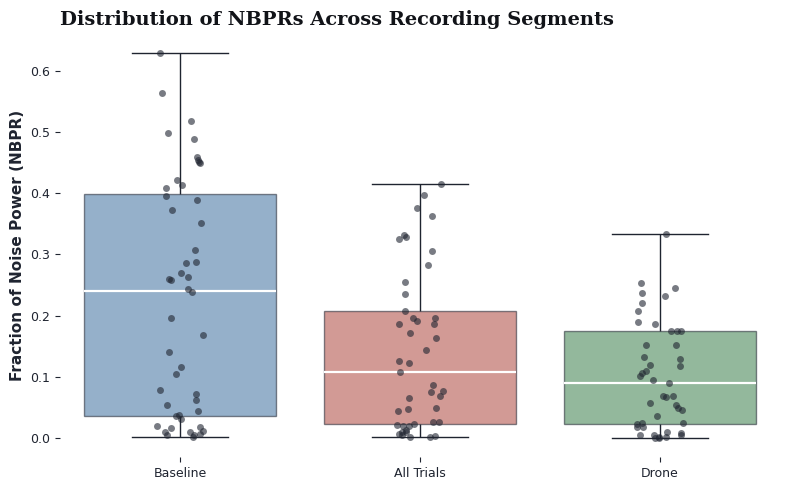

In [13]:
cols = [
    "NBPR_Baseline",
    "NBPR_All_Trials",
    "NBPR_Drone"
]

df_plot = segmented_df[cols].copy()

df_plot.columns = [
    "Baseline",
    "All Trials",
    "Drone"
]

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor(THEME["figure_bg"])

palette = DARK_PALETTE[:df_plot.shape[1]]

sns.boxplot(
    data=df_plot,
    palette=palette,
    showfliers=False,
    boxprops=dict(alpha=0.55, edgecolor=THEME["text_color"]),
    whiskerprops=dict(color=THEME["text_color"]),
    capprops=dict(color=THEME["text_color"]),
    medianprops=dict(color="white", linewidth=1.6),
    ax=ax,
)

sns.stripplot(
    data=df_plot,
    color=THEME["text_color"],
    alpha=0.6,
    jitter=True,
    size=5,
    linewidth=0,
    ax=ax,
)

style_dark_axes(
    ax,
    title="Distribution of NBPRs Across Recording Segments",
    xlabel="",
    ylabel="Fraction of Noise Power (NBPR)",
)

fig.tight_layout()
plt.savefig("Figure_X_NBPRs.png", dpi=600, bbox_inches="tight")

#### Comparison of NBPR across devices

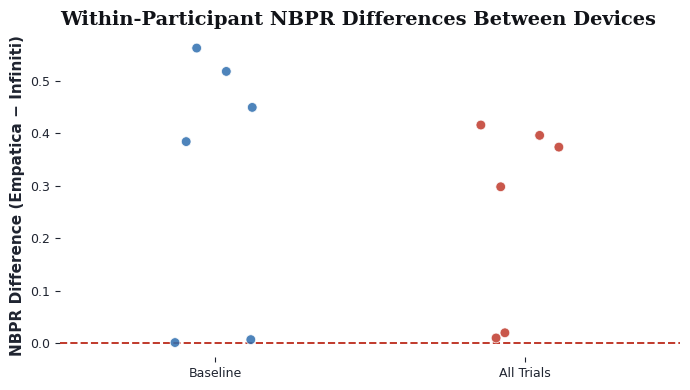

In [14]:
within_diff = segmented_df_comparison.merge(
    segmented_df_inf,
    on="participant_id",
    suffixes=("_comp", "_inf")
)

within_diff["NBPR_Baseline_diff"] = within_diff["NBPR_Baseline_comp"] - within_diff["NBPR_Baseline_inf"]
within_diff["NBPR_All_Trials_diff"] = within_diff["NBPR_All_Trials_comp"] - within_diff["NBPR_All_Trials_inf"]

plot_df = within_diff.melt(
    id_vars=["participant_id"],
    value_vars=["NBPR_Baseline_diff", "NBPR_All_Trials_diff"],
    var_name="Segment",
    value_name="NBPR_Difference"
)

plot_df["Segment"] = plot_df["Segment"].replace({
    "NBPR_Baseline_diff": "Baseline",
    "NBPR_All_Trials_diff": "All Trials"
})

fig, ax = plt.subplots(figsize=(7, 4))
fig.patch.set_facecolor(THEME["figure_bg"])

sns.stripplot(
    data=plot_df,
    x="Segment",
    y="NBPR_Difference",
    hue="Segment",
    palette=DARK_PALETTE[:plot_df["Segment"].nunique()],
    alpha=0.85,
    jitter=0.15,
    size=7,
    linewidth=0.6,
    edgecolor="white",
    legend=False,
    ax=ax,
)

ax.axhline(0, color=THEME["loa_color"], linestyle="--", linewidth=1.4, zorder=1)

style_dark_axes(
    ax,
    title="Within-Participant NBPR Differences Between Devices",
    xlabel="",
    ylabel="NBPR Difference (Empatica − Infiniti)",
)

fig.tight_layout()
plt.savefig("Figure_X_NBPR_Diffs.png", dpi=600, bbox_inches="tight")

## Index-Level Validation

### Agreement between Empatica and Infiniti regarding the SCR and SCL

In [15]:
def compute_components(signal, sampling_rate=4):
    
    # --- reject None / NaN / empty ---
    if signal is None:
        return None, None

    # convert early (safe handling of lists, arrays, NaNs)
    signal = np.asarray(signal, dtype=float)

    # reject NaN-only or empty signals
    if signal.size == 0 or np.all(np.isnan(signal)):
        return None, None

    # remove NaNs inside signal (important for NeuroKit)
    signal = signal[~np.isnan(signal)]

    if len(signal) < 10:
        return None, None

    try:
        out = nk.eda_phasic(signal, sampling_rate=sampling_rate, method="cvxEDA")
        tonic = out["EDA_Tonic"].values
        phasic = out["EDA_Phasic"].values
        return tonic, phasic

    except Exception:
        return None, None
    
def safe_xcorr(a, b, max_lag=12, min_overlap=1120): #at least 4:40 minutes of overlap at 4 Hz sampling rate
    """
    Cross-correlation with lag search.

    Slides `b` relative to `a` across lags in [-max_lag, +max_lag] samples
    and returns the Pearson correlation (and the lag) at which r is
    maximized, computed only on the overlapping portion of the two signals
    at each lag.

    Convention: lag > 0 means `b` lags behind `a` by `lag` samples
    (i.e. b's response occurs `lag` samples later than a's); lag < 0
    means `b` leads `a`.

    Returns
    -------
    best_r : float — correlation at the best lag (NaN if no valid lag found)
    best_lag : int — lag (in samples) at which r was maximized
    """
    if a is None or b is None:
        return np.nan, np.nan

    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    if len(a) == 0 or len(b) == 0:
        return np.nan, np.nan

    n = min(len(a), len(b))
    a = a[:n]
    b = b[:n]

    if np.std(a) == 0 or np.std(b) == 0:
        return np.nan, np.nan

    best_r = np.nan
    best_lag = np.nan

    for lag in range(-max_lag, max_lag + 1):

        if lag >= 0:
            a_seg = a[: n - lag] if lag > 0 else a
            b_seg = b[lag:]
        else:
            a_seg = a[-lag:]
            b_seg = b[: n + lag]

        if len(a_seg) < min_overlap:
            continue
        if np.std(a_seg) == 0 or np.std(b_seg) == 0:
            continue

        r = pearsonr(a_seg, b_seg)[0] #other's have demeaned or detrended signals, but Pearson's r is already invariant to linear transformations

        if np.isnan(r):
            continue

        if np.isnan(best_r) or r > best_r:
            best_r = r
            best_lag = lag

    return best_r, best_lag


results = []

for pid in segmented_df_comparison["participant_id"]:

    row_inf = segmented_df_inf[segmented_df_inf["participant_id"] == pid]
    row_comp = segmented_df_comparison[segmented_df_comparison["participant_id"] == pid]

    if row_inf.empty or row_comp.empty:
        continue

    inf_base = row_inf["Baseline_cleaned"].iloc[0]
    comp_base = row_comp["Baseline_cleaned"].iloc[0]

    inf_trial = row_inf["All_Trials_cleaned"].iloc[0]
    comp_trial = row_comp["All_Trials_cleaned"].iloc[0]

    # --- Decompose ---
    inf_base_t, inf_base_p = compute_components(inf_base)
    comp_base_t, comp_base_p = compute_components(comp_base)

    inf_trial_t, inf_trial_p = compute_components(inf_trial)
    comp_trial_t, comp_trial_p = compute_components(comp_trial)

    # --- Cross-correlate with lag search (max ±120 samples = ±30 s @ 4 Hz) ---
    corr_tonic_baseline, lag_tonic_baseline = safe_xcorr(inf_base_t, comp_base_t, max_lag=40)
    corr_phasic_baseline, lag_phasic_baseline = safe_xcorr(inf_base_p, comp_base_p, max_lag=40)

    corr_tonic_trials, lag_tonic_trials = safe_xcorr(inf_trial_t, comp_trial_t, max_lag=40)
    corr_phasic_trials, lag_phasic_trials = safe_xcorr(inf_trial_p, comp_trial_p, max_lag=40)

    results.append({
        "participant_id": pid,

        # Baseline
        "corr_tonic_baseline": corr_tonic_baseline,
        "lag_tonic_baseline": lag_tonic_baseline,
        "corr_phasic_baseline": corr_phasic_baseline,
        "lag_phasic_baseline": lag_phasic_baseline,

        # Trials
        "corr_tonic_trials": corr_tonic_trials,
        "lag_tonic_trials": lag_tonic_trials,
        "corr_phasic_trials": corr_phasic_trials,
        "lag_phasic_trials": lag_phasic_trials,
    })

corr_df = pd.DataFrame(results)
corr_df.describe()

,corr_tonic_baseline,lag_tonic_baseline,corr_phasic_baseline,lag_phasic_baseline,corr_tonic_trials,lag_tonic_trials,corr_phasic_trials,lag_phasic_trials
count,6.000000,6.000000,6.000000,6.000000,5.000000,5.000000,5.000000,5.000000
mean,-0.454259,0.000000,0.117861,-10.833333,0.100794,-5.800000,0.091660,14.800000
std,0.306266,35.777088,0.176805,20.759737,0.549963,34.470277,0.042957,29.642874
min,-0.865397,-40.000000,-0.004987,-40.000000,-0.671741,-40.000000,0.030698,-31.000000
25%,-0.620633,-30.000000,0.007200,-26.000000,-0.164445,-40.000000,0.064099,2.000000
50%,-0.458161,0.000000,0.063216,1.500000,0.170395,0.000000,0.113816,26.000000
75%,-0.334197,30.000000,0.117730,2.000000,0.398930,11.000000,0.114549,37.000000
max,0.023831,40.000000,0.461292,5.000000,0.770828,40.000000,0.135138,40.000000


The values look terrible! Let's check the raw data and see whether this is realistic or if we maybe made a mistake after all.
Let's check the first couple values of the first trial of our first participant for both devices

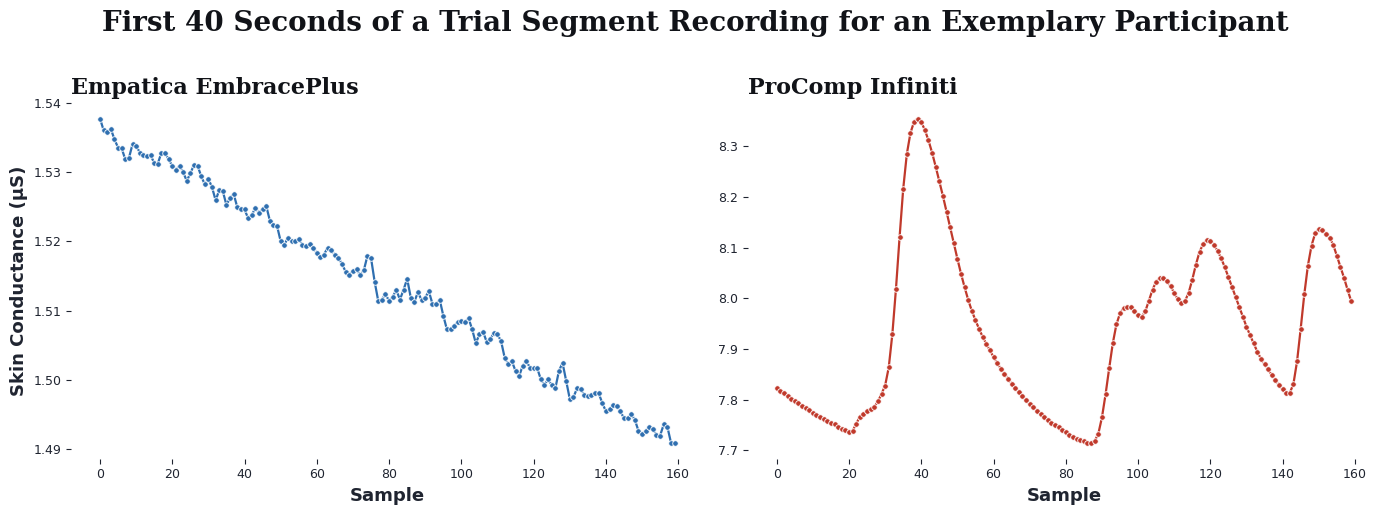

In [16]:
#These are the first 20 seconds of the Empatica's data in the first trial of a participant wearing both devices 
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
fig.patch.set_facecolor(THEME["figure_bg"])


sig1 = segmented_df_comparison[segmented_df_comparison["participant_id"] == "OITC39"]["Trial_1"].to_numpy()[0][0:160]
axes[0].plot(
    sig1,
    color=DARK_PALETTE[0], linewidth=1.6,
    marker="o", markersize=4,
    markerfacecolor=DARK_PALETTE[0], markeredgecolor="white", markeredgewidth=0.6,
)
style_dark_axes(axes[0], title="Empatica EmbracePlus", xlabel="Sample", ylabel="Skin Conductance (µS)", fontsize=16)

sig2 = segmented_df_inf[segmented_df_inf["participant_id"] == "OITC39"]["Trial_1"].to_numpy()[0][0:160]
axes[1].plot(
    sig2,
    color=DARK_PALETTE[1], linewidth=1.6,
    marker="o", markersize=4,
    markerfacecolor=DARK_PALETTE[1], markeredgecolor="white", markeredgewidth=0.6,
)
style_dark_axes(axes[1], title="ProComp Infiniti", xlabel="Sample", ylabel="", fontsize=16)

fig.suptitle(
    "First 40 Seconds of a Trial Segment Recording for an Exemplary Participant",
     fontsize=20, fontweight="bold", family="serif", y=1.02, color=THEME["title_color"]
)
fig.tight_layout()
plt.savefig("Figure_X_Across_Device_Raw.png", dpi=600, bbox_inches="tight")

We can see that the wrist-worn device does not capture meaningful SCRs and only random spikey noise in comparison to the reference.
We can also observe a very peculiar downward trend in the SCL for this brief recording sample...opposite to what is usually obseved.


In [17]:
def extract_interval_metrics(signal, sampling_rate=4):

    if signal is None:
        return None

    signal = np.asarray(signal, dtype=float).flatten()
    signal = signal[~np.isnan(signal)]

    if len(signal) < 10:
        return None

    try:

        signal = nk.signal_filter(
            signal,
            sampling_rate=sampling_rate,
            lowcut=None,
            highcut=0.6,
            method="butterworth",
            order=6
        ) # remove high-frequency noise (e.g. Kong et al., 2021), we are trying to do the Empatica a solid here, since the noise is just ridiculous

        # =====================================================
        # 1. Sympathetic metrics (5 min windows)
        # =====================================================

        symp_window = 300 * sampling_rate 

        sympathetic_values = []
        sympatheticN_values = []

        for start in range(0, len(signal), symp_window):

            segment = signal[start:start + symp_window]

            # Skip incomplete windows
            if len(segment) < symp_window:
                continue

            try:
                symp = nk.eda_sympathetic(
                    segment,
                    sampling_rate=sampling_rate,
                    method="ghiasi", #The Posada-Quintero-method requires a 400Hz resampling which leads to weird estimates. Ghiasi only does 50Hz.
                    show=False 
                )

                sympathetic_values.append(symp["EDA_Sympathetic"])
                sympatheticN_values.append(symp["EDA_SympatheticN"])

            except Exception:
                continue

        eda_sympathetic = (
            np.nanmean(sympathetic_values)
            if len(sympathetic_values) > 0
            else np.nan
        )

        eda_sympatheticN = (
            np.nanmean(sympatheticN_values)
            if len(sympatheticN_values) > 0
            else np.nan
        )

        # =====================================================
        # 2. Phasic decomposition
        # =====================================================

        decomp = nk.eda_phasic(
            signal,
            sampling_rate=sampling_rate,
            method="cvxEDA"
        )

        phasic = decomp["EDA_Phasic"].values
        tonic = decomp["EDA_Tonic"].values

        # =====================================================
        # 3. SCR metrics (60-second windows)
        # =====================================================

        scr_window = 60 * sampling_rate  # 240 samples @ 4 Hz

        scr_n_values = []
        scr_amp_values = []

        for start in range(0, len(phasic), scr_window):

            segment = phasic[start:start + scr_window]

            # Skip incomplete windows
            if len(segment) < scr_window:
                continue

            try:

                _, peaks = nk.eda_peaks(
                    segment,
                    sampling_rate=sampling_rate,
                    amplitude_min=0.001
                )

                valid_peaks = peaks["SCR_Amplitude"] >= 0.05 #we set this minimum amplitude threshold to 0.05 µS, as recommended by Bizzego et al. (2020)

                scr_n = np.sum(valid_peaks)

                if scr_n > 0:
                    scr_amp = np.mean(
                        peaks["SCR_Amplitude"][valid_peaks]
                    )
                else:
                    scr_amp = 0.0

                scr_n_values.append(scr_n)
                scr_amp_values.append(scr_amp)

            except Exception:
                continue

        mean_scr_n = (
            np.nanmean(scr_n_values)
            if len(scr_n_values) > 0
            else 0.0
        )

        mean_scr_amp = (
            np.nanmean(scr_amp_values)
            if len(scr_amp_values) > 0
            else 0.0
        )

        return {
            "SCR_Peaks_per_minute": float(mean_scr_n),
            "SCR_Peaks_Amplitude_Mean": float(mean_scr_amp),
            "EDA_Sympathetic": float(eda_sympathetic),
            "EDA_SympatheticN": float(eda_sympatheticN),
            "Phasic_Mean": float(np.mean(phasic)),
            "Tonic_Mean": float(np.mean(tonic)),
        }

    except Exception:
        return {
            "SCR_Peaks_per_minute": np.nan,
            "SCR_Peaks_Amplitude_Mean": np.nan,
            "EDA_Sympathetic": np.nan,
            "EDA_SympatheticN": np.nan,
        }
    
def build_interval_df(df, device_name):

    rows = []

    for _, r in df.iterrows():
        pid = r["participant_id"]
        print(f"Processing participant {pid} for device {device_name}")

        for segment in ["Baseline_cleaned", "All_Trials_cleaned", "Trial_1_cleaned", "Trial_2_cleaned", "Trial_3_cleaned"]:

            metrics = extract_interval_metrics(r[segment])

            if metrics is None:
                continue

            # build one row per participant-device-segment
            rows.append({
                "participant_id": pid,
                "device": device_name,
                "segment": segment.replace("_cleaned", ""),
                **metrics   
            })

    return pd.DataFrame(rows)

df_inf = build_interval_df(segmented_df_inf, "Infiniti")
df_comp = build_interval_df(segmented_df_comparison, "Empatica")

eda_interval_long = pd.concat([df_inf, df_comp], ignore_index=True)


Processing participant OITC39 for device Infiniti
Processing participant OITC40 for device Infiniti
Processing participant OITC44 for device Infiniti
Processing participant OITC45 for device Infiniti
Processing participant OITC46 for device Infiniti
Processing participant OITC50 for device Infiniti
Processing participant OITC39 for device Empatica
Processing participant OITC40 for device Empatica
Processing participant OITC44 for device Empatica
Processing participant OITC45 for device Empatica
Processing participant OITC46 for device Empatica
Processing participant OITC50 for device Empatica


In [18]:
eda_interval_long.to_csv("eda_indices_table.csv", index=False)

A little spoiler here already: the Empatica did not produce any valid SCRs, we only see jitter there.
Subsequently, nSCR/minute and mean SCR-Amplitude are essentially useless. 
At this point it is also obvious why calculating any form of reliability metrics (like split-half within segments) for the Empatica would give it more credit than it deserves. Reliably measuring "nothing" does not conform to our understanding of useful data acquisition. 

### Easily Run Index-Level and Event-Level Analysis
Can be done from here with the intermediate data saved in the csv file without needing the prior processing etc.

<!-- ### Easily Run Index-Level and Event-Level Analysis 
Can be done from here without needing any preprocessing and with higher order indices that were intermediately saved in the csv file -->

In [19]:
import pandas as pd
import numpy as np
import datetime as dt
from datetime import timedelta
import neurokit2 as nk
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from pathlib import Path
import re
from scipy import stats
from scipy.stats import wilcoxon, pearsonr, zscore
import statsmodels.formula.api as smf
import matplotlib.transforms as transforms



# suppress all NeuroKit warnings
warnings.filterwarnings(
    "ignore",
    module="neurokit2"
)


#this theme isn't dark at all anymore but we kept the name just out of laziness ;)
DARK_PALETTE = ["#2f6fb0", "#c0392b", "#2e8b45", "#7b4fa0", "#c98a1a", "#2f9e9e"] 

THEME = {
    "figure_bg": "#ffffff",
    "axes_bg": "#ffffff",
    "grid_color": "#ffffff",
    "text_color": "#1f2430",
    "title_color": "#111318",
    "point_color": "#4a4f5a",
    "point_alpha": 0.55,
    "bias_color": "#7b4fa0",
    "theoretical_color": "#2e8b45",
    "loa_color": "#c0392b",
    "annotation_color": "#1f2430",
}

def _style_axis(ax, labelsize = 9):
    ax.set_facecolor(THEME["axes_bg"])
    ax.grid(True, color=THEME["grid_color"], linewidth=0.7, alpha=0.6)
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(colors=THEME["text_color"], labelsize=labelsize)
    ax.xaxis.label.set_color(THEME["text_color"])
    ax.yaxis.label.set_color(THEME["text_color"])

def style_dark_axes(ax, title=None, xlabel=None, ylabel=None, legend_title=None, fontsize = 14):
    """
    Apply the shared light theme (background, grid, spines, fonts) to any
    matplotlib/seaborn Axes -- not just Bland-Altman panels. Use this for
    lineplots, barplots, etc. to keep a consistent look across a report.

    (Function name kept as `style_dark_axes` for compatibility with the
    rest of the notebook, despite the theme now being light.)
    """
    fig = ax.get_figure()
    fig.patch.set_facecolor(THEME["figure_bg"])
    _style_axis(ax)

    if title is not None:
        ax.set_title(title, color=THEME["title_color"], fontsize=fontsize,
                     fontweight="bold", loc="left", family="serif")
    if xlabel is not None:
        ax.set_xlabel(xlabel, fontsize=fontsize - 3, fontweight="bold")
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=fontsize - 3, fontweight="bold")

    legend = ax.get_legend()
    if legend is not None:
        legend.get_frame().set_facecolor(THEME["axes_bg"])
        legend.get_frame().set_edgecolor(THEME["grid_color"])
        for text in legend.get_texts():
            text.set_color(THEME["text_color"])
        if legend_title is not None:
            legend.set_title(legend_title)
        if legend.get_title() is not None:
            legend.get_title().set_color(THEME["text_color"])

    return ax

eda_interval_long = pd.read_csv("eda_indices_table.csv")
eda_interval_long.head()

,participant_id,device,segment,SCR_Peaks_per_minute,SCR_Peaks_Amplitude_Mean,EDA_Sympathetic,EDA_SympatheticN,Phasic_Mean,Tonic_Mean
0,OITC39,Infiniti,Baseline,3.8,0.301849,0.219370,0.069089,0.178059,6.259089
1,OITC39,Infiniti,All_Trials,4.2,0.239708,1.239754,0.064961,0.128979,7.933352
2,OITC39,Infiniti,Trial_1,4.6,0.214942,1.841646,0.074116,0.100374,7.726994
3,OITC39,Infiniti,Trial_2,4.0,0.268273,1.354645,0.054568,0.112537,7.868683
4,OITC39,Infiniti,Trial_3,4.4,0.252693,0.523005,0.066197,0.169307,8.209106


### Device Agreement via Bland-Altmann-Plots
Following guidelines of van Lier et al. (2020)

We will skip redundant analysis on the amplitude again and only show that nSCR does not work here and give it another shot with the frequency-derived indicator of sympathetic activity of Posada-Quintero et al. (2016) and the Phasic "jitter" at least.

Preparing Bland–Altman data for EDA_SympatheticN: 26/30 complete pairs, 4 missing.
Preparing Bland–Altman data for SCR_Peaks_per_minute: 26/30 complete pairs, 4 missing.
Preparing Bland–Altman data for Phasic_Mean: 26/30 complete pairs, 4 missing.
Preparing Bland–Altman data for Tonic_Mean: 26/30 complete pairs, 4 missing.


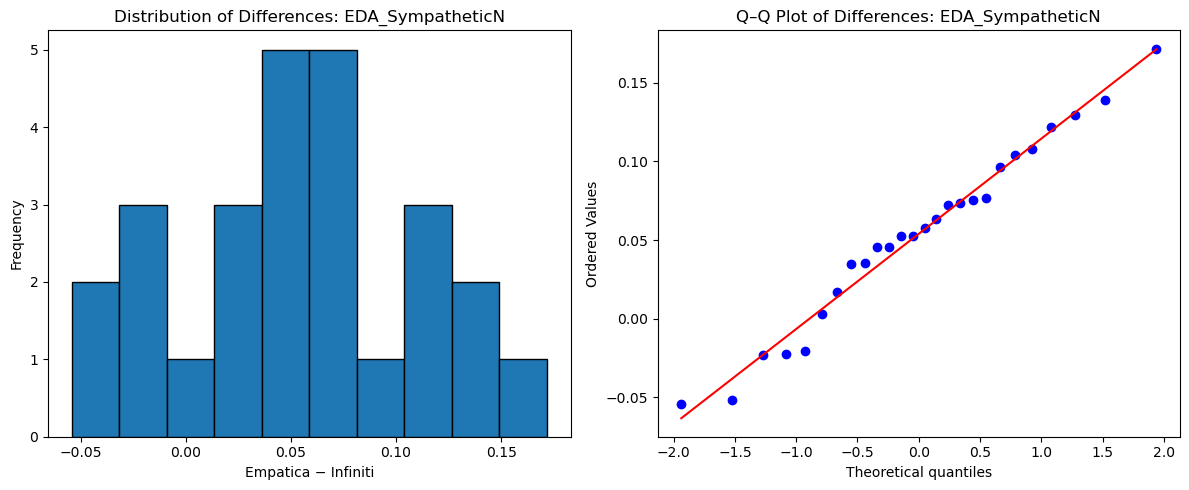

In [20]:
# We will use a helper function to prepare the data for Bland-Altman analysis. This function will pair the observations by participant and segment, compute the mean and difference between the two devices.
def prepare_bland_altman_data(df, variable):

    # Pair devices within participant × segment
    paired = (
        df.pivot(
            index=["participant_id", "segment"],
            columns="device",
            values=variable
        )
        .reset_index()
        .rename_axis(columns=None)
    )

    # Number of potential pairs
    n_total = len(paired)

    # Keep only complete pairs
    paired = paired.dropna(
        subset=["Infiniti", "Empatica"]
    ).copy()

    n_complete = len(paired)
    n_missing = n_total - n_complete

    print(
        f"Preparing Bland–Altman data for {variable}: "
        f"{n_complete}/{n_total} complete pairs, "
        f"{n_missing} missing."
    )

    # Bland–Altman quantities
    paired["mean"] = (
        paired["Empatica"] + paired["Infiniti"]
    ) / 2

    paired["difference"] = (
        paired["Empatica"] - paired["Infiniti"]
    )

    return paired


# We will also check normality straight away
def plot_difference_normality(paired, variable):
    differences = paired["difference"]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Histogram
    axes[0].hist(
        differences,
        bins=10,
        edgecolor="black"
    )
    axes[0].set_xlabel("Empatica − Infiniti")
    axes[0].set_ylabel("Frequency")
    axes[0].set_title(f"Distribution of Differences: {variable}")

    # Q-Q plot
    stats.probplot(
        differences,
        dist="norm",
        plot=axes[1]
    )
    axes[1].set_title(f"Q–Q Plot of Differences: {variable}")

    plt.tight_layout()
    plt.show()


paired_eda_SN = prepare_bland_altman_data(eda_interval_long, "EDA_SympatheticN")
paired_eda_peaks_minute = prepare_bland_altman_data(eda_interval_long, "SCR_Peaks_per_minute")
paired_eda_phasic = prepare_bland_altman_data(eda_interval_long, "Phasic_Mean")
paired_eda_tonic = prepare_bland_altman_data(eda_interval_long, "Tonic_Mean")

plot_difference_normality(
    paired_eda_SN,
    "EDA_SympatheticN"
)

Close enough! The data does not explicitly speak against normality

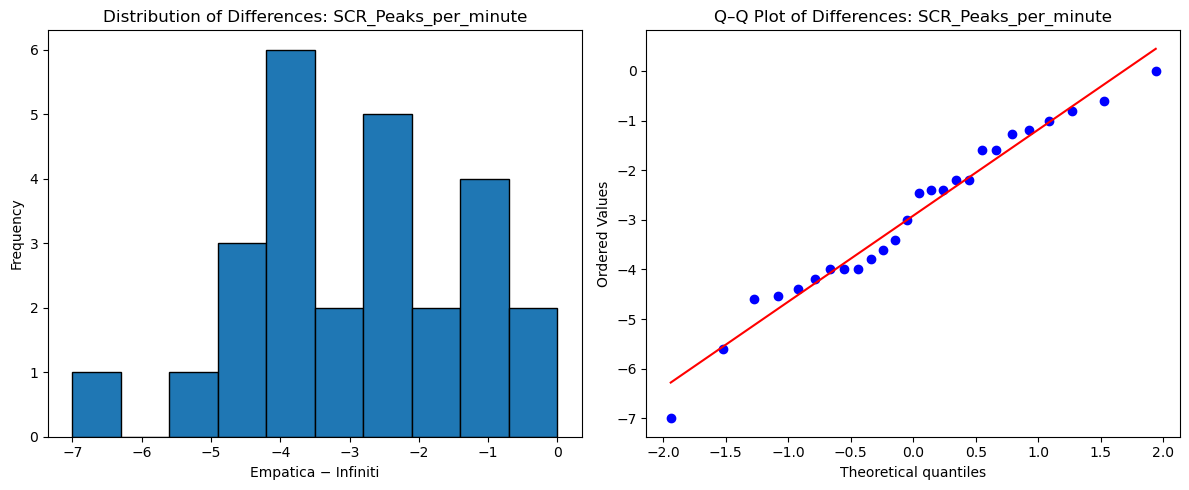

In [21]:
plot_difference_normality(
    paired_eda_peaks_minute,
    "SCR_Peaks_per_minute"
)

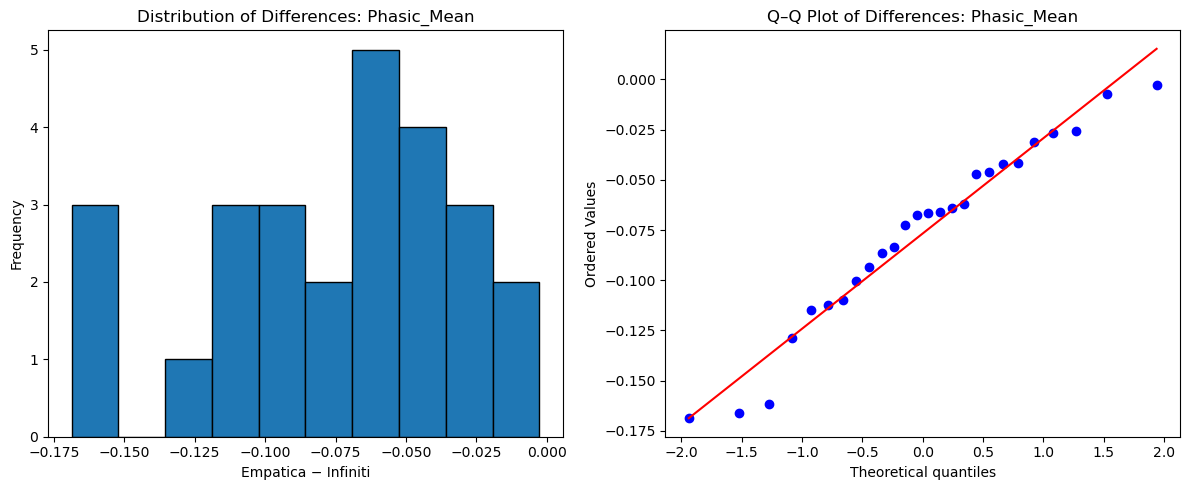

In [22]:
plot_difference_normality(
    paired_eda_phasic,
    "Phasic_Mean"
)

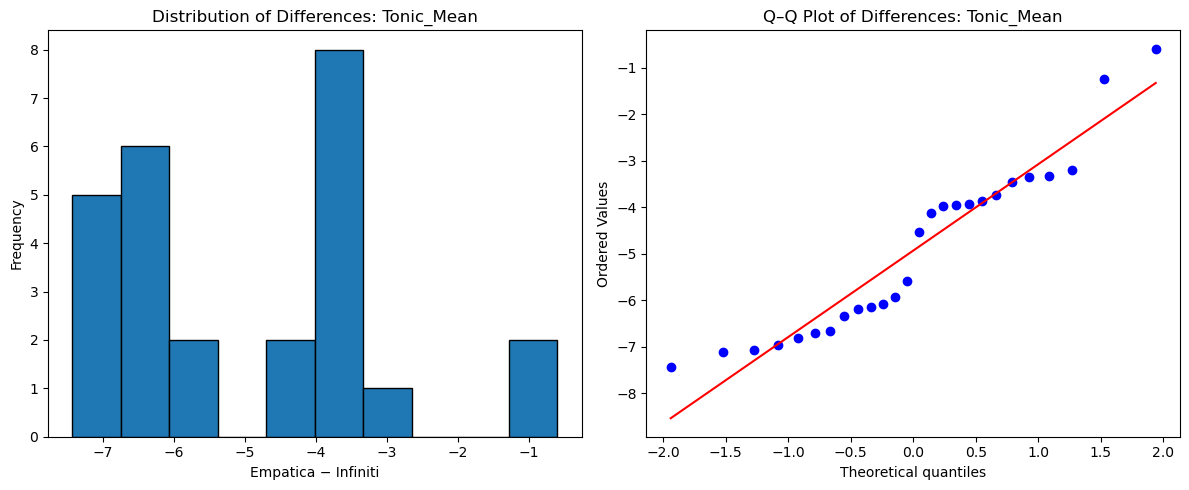

In [23]:
plot_difference_normality(
    paired_eda_tonic,
    "Tonic_Mean"
)

Not too pretty, but again, it does not explicitly speak against normality and mostly serves as illustration anyways. We do only qualitative interpretation of this anyhow and are not to stuck-up on the LoA at this sample size. 

In [24]:
"""
Bland-Altman plotting utilities styled to match a dark-theme, multi-panel
report layout: dark navy background, purple bias line, green theoretical
(clinically acceptable) boundaries, red statistical limits of agreement
(LoA), and an inline "% of data inside boundaries" annotation.

Assumption about the reference figure's color coding (adjust via the
`colors` dict if your intent differs):
    - purple line  -> mean bias
    - green lines  -> theoretical / clinically acceptable boundaries
                      (user-supplied, e.g. from literature)
    - red lines    -> statistical 95% limits of agreement (bias +/- 1.96*SD)
    - annotation   -> % of observations inside the THEORETICAL (green)
                      boundaries, since that's the clinically meaningful
                      question ("how much of our data is acceptable?")
"""
# ---- Visual theme -----------------------------------------------------

THEME = {
    "figure_bg": "#ffffff",
    "axes_bg": "#ffffff",
    "grid_color": "#ffffff",
    "text_color": "#1f2430",
    "title_color": "#111318",
    "point_color": "#3d4552",
    "point_alpha": 0.45,
    "bias_color": "#8e24aa",
    "theoretical_color": "#1a9850",
    "loa_color": "#e0301e",
    "annotation_color": "#1f2430",
}


def bland_altman_analysis(paired, diff_col="difference"):
    """Compute bias and 95% statistical limits of agreement (LoA)."""
    differences = paired[diff_col]
    n = len(differences)
    mean_difference = differences.mean()
    sd_difference = differences.std(ddof=1)

    loa_lower = mean_difference - 1.96 * sd_difference
    loa_upper = mean_difference + 1.96 * sd_difference

    return {
        "n": n,
        "bias": mean_difference,
        "sd_difference": sd_difference,
        "loa_lower": loa_lower,
        "loa_upper": loa_upper,
    }


def _style_axis(ax):
    ax.set_facecolor(THEME["axes_bg"])
    ax.grid(True, color=THEME["grid_color"], linewidth=0.7, alpha=0.6)
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(colors=THEME["text_color"], labelsize=9)
    ax.xaxis.label.set_color(THEME["text_color"])
    ax.yaxis.label.set_color(THEME["text_color"])


def plot_bland_altman(
    paired,
    mean_col,
    diff_col,
    theoretical_lower=None,
    theoretical_upper=None,
    title="",
    xlabel=None,
    ylabel=None,
    ax=None,
    colors=None,
):
    """
    Draw a single Bland-Altman panel in the reference dark-theme style.

    Parameters
    ----------
    paired : pd.DataFrame
        Must contain `mean_col` and `diff_col`.
    theoretical_lower, theoretical_upper : float, optional
        Clinically/theoretically acceptable boundaries (green lines).
        If omitted, only bias + statistical LoA are drawn.
    ax : matplotlib.axes.Axes, optional
        Existing axis to draw into (for building custom grids).
    colors : dict, optional
        Overrides for THEME entries (e.g. {"loa_color": "#ff0000"}).
    """
    c = {**THEME, **(colors or {})}
    stats = bland_altman_analysis(paired, diff_col=diff_col)
    means = paired[mean_col]
    diffs = paired[diff_col]
    n = stats["n"]

    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(5.2, 4.2))
        fig.patch.set_facecolor(c["figure_bg"])

    _style_axis(ax)

    # Scatter
    ax.scatter(
        means, diffs,
        s=28, color=c["point_color"], alpha=c["point_alpha"],
        edgecolor="none", zorder=3,
    )

    # Bias line (purple)
    ax.axhline(stats["bias"], color=c["bias_color"], linewidth=1.4, zorder=2)

    # Statistical LoA (red)
    ax.axhline(stats["loa_upper"], color=c["loa_color"], linewidth=1.2, zorder=2)
    ax.axhline(stats["loa_lower"], color=c["loa_color"], linewidth=1.2, zorder=2)

    # Blended transform: x in axes-fraction (fixed to the right side),
    # y in data coordinates (tracks the line) -> labels never overlap the line
    blended = transforms.blended_transform_factory(ax.transAxes, ax.transData)

    ax.annotate(
        f"Upper bound = {stats['loa_upper']:.3f}",
        xy=(0.98, stats["loa_upper"]), xycoords=blended,
        xytext=(0, 4), textcoords="offset points",
        color=c["annotation_color"], fontsize=8.5, va="bottom", ha="right", zorder=4,
    )
    ax.annotate(
        f"Lower bound = {stats['loa_lower']:.3f}",
        xy=(0.98, stats["loa_lower"]), xycoords=blended,
        xytext=(0, -4), textcoords="offset points",
        color=c["annotation_color"], fontsize=8.5, va="top", ha="right", zorder=4,
    )

    # Theoretical bounds (green) + % inside annotation
    if theoretical_lower is not None and theoretical_upper is not None:
        ax.axhline(theoretical_upper, color=c["theoretical_color"], linewidth=1.4, zorder=2)
        ax.axhline(theoretical_lower, color=c["theoretical_color"], linewidth=1.4, zorder=2)

        inside = (diffs >= theoretical_lower) & (diffs <= theoretical_upper)
        pct_inside = inside.sum() / n * 100

        # Fixed corner placement (axes-fraction coords) so it never
        # collides with the bias/LoA/theoretical lines, regardless of
        # how close together those lines happen to fall.
        ax.annotate(
            f"{pct_inside:.0f} % of the data lies inside the boundaries.",
            xy=(0.02, 0.03), xycoords="axes fraction",
            color=c["annotation_color"], fontsize=8.5, va="bottom", ha="left", zorder=5,
            bbox=dict(boxstyle="round,pad=0.35", facecolor=c["axes_bg"],
                      edgecolor=c["theoretical_color"], linewidth=0.8, alpha=0.92),
        )

    ax.set_title(title, color=c["title_color"], fontsize=13, fontweight="bold",
                 loc="left", family="serif")
    ax.set_xlabel(xlabel if xlabel else mean_col, fontsize=10, fontweight="bold")
    ax.set_ylabel(ylabel if ylabel else diff_col, fontsize=10, fontweight="bold")

    if own_fig:
        fig.tight_layout()
        return fig, ax
    return ax


def plot_bland_altman_grid(panels, ncols=2, figsize_per_panel=(6.2, 5.2), colors=None):
    """
    Draw multiple Bland-Altman panels in a single dark-themed grid figure,
    matching the reference multi-panel report layout.

    Parameters
    ----------
    panels : list of dict
        Each dict is passed as kwargs to `plot_bland_altman`, e.g.:
        {
            "paired": df, "mean_col": "mean_scl", "diff_col": "diff_scl",
            "theoretical_lower": -1.0, "theoretical_upper": 1.0,
            "title": "Mean log(SCL)", "xlabel": "...", "ylabel": "...",
        }
    ncols : int
        Number of columns in the grid.
    """
    c = {**THEME, **(colors or {})}
    n_panels = len(panels)
    nrows = int(np.ceil(n_panels / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(figsize_per_panel[0] * ncols, figsize_per_panel[1] * nrows),
    )
    fig.patch.set_facecolor(c["figure_bg"])
    axes = np.atleast_1d(axes).flatten()

    for ax, panel_kwargs in zip(axes, panels):
        plot_bland_altman(ax=ax, colors=colors, **panel_kwargs)

    # Hide unused axes if grid isn't fully filled
    for ax in axes[n_panels:]:
        ax.set_visible(False)

    plt.savefig("Figure_X_Bland_Altman_Grid.png", dpi=600, bbox_inches="tight")
    return fig, axes

(<Figure size 1240x1040 with 4 Axes>,
 array([<Axes: title={'left': 'Phasic Mean'}, xlabel='Mean Phasic EDA (Empatica, Infiniti) (µS)', ylabel='Difference (Empatica − Infiniti) (µS)'>,
        <Axes: title={'left': 'Tonic Mean'}, xlabel='Mean Tonic EDA (Empatica, Infiniti) (µS)', ylabel='Difference (Empatica − Infiniti) (µS)'>,
        <Axes: title={'left': 'SCR Peaks per Minute'}, xlabel='Mean SCR Peaks per Minute (Empatica, Infiniti)', ylabel='Difference (Empatica − Infiniti)'>,
        <Axes: title={'left': 'EDA Sympathetic Indicator (n.u.)'}, xlabel='Mean Sympathetic Indicator (Empatica, Infiniti) (n.u.)', ylabel='Difference (Empatica − Infiniti) (n.u.)'>],
       dtype=object))

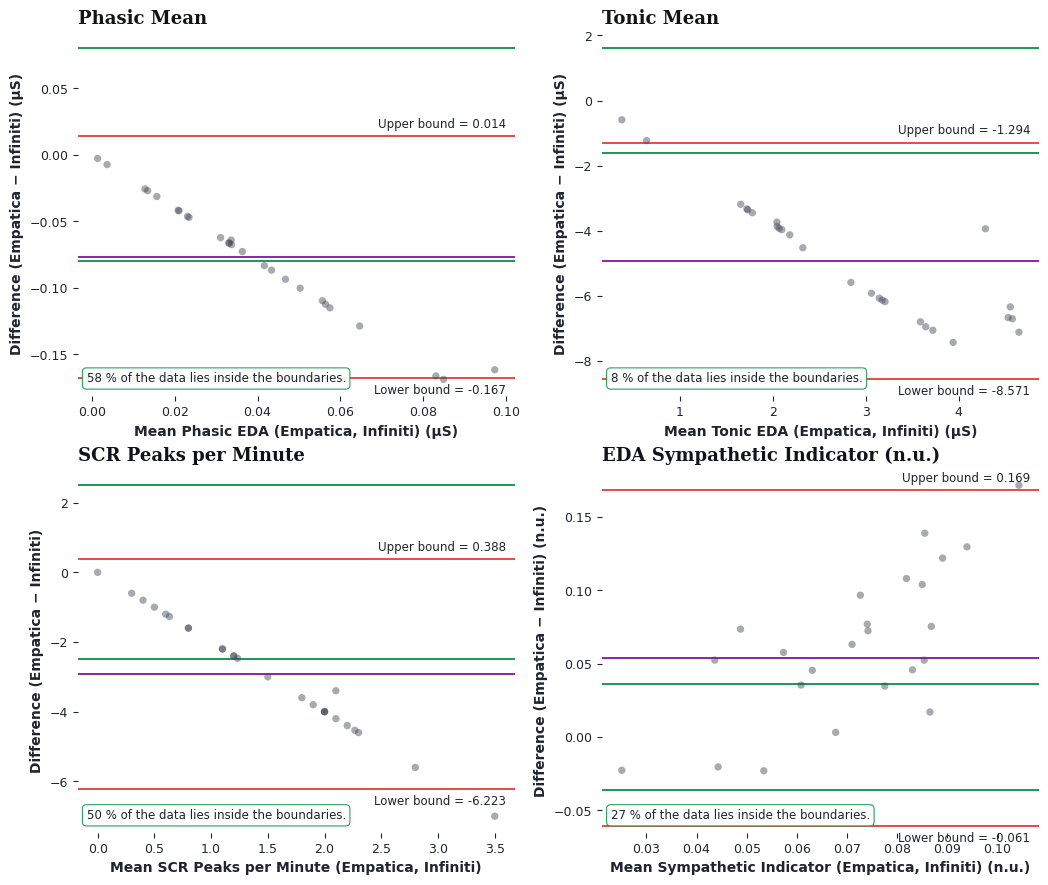

In [25]:
plot_bland_altman_grid(
    panels=[
        {
            "paired": paired_eda_phasic,
            "mean_col": "mean",
            "diff_col": "difference",
            "theoretical_lower": -0.08,        #boundaries based on Dawson et al. (2017): SCR Responses range= 0.8 
            "theoretical_upper": 0.08,
            "title": "Phasic Mean",
            "xlabel": "Mean Phasic EDA (Empatica, Infiniti) (µS)",
            "ylabel": "Difference (Empatica − Infiniti) (µS)",
        },

        {
            "paired": paired_eda_tonic,
            "mean_col": "mean",
            "diff_col": "difference",
            "theoretical_lower": -1.6,        #boundaries based on van Lier et al. (2020): SCR Responses range= 16 
            "theoretical_upper": 1.6,
            "title": "Tonic Mean",
            "xlabel": "Mean Tonic EDA (Empatica, Infiniti) (µS)",
            "ylabel": "Difference (Empatica − Infiniti) (µS)",
        },
        
        {
            "paired": paired_eda_peaks_minute,
            "mean_col": "mean",
            "diff_col": "difference",
            "theoretical_lower": -2.5,      #boundaries based on van Lier et al. (2020): 25 SCR peaks per minute
            "theoretical_upper": 2.5,
            "title": "SCR Peaks per Minute",
            "xlabel": "Mean SCR Peaks per Minute (Empatica, Infiniti)",
            "ylabel": "Difference (Empatica − Infiniti)",
        },

        {
            "paired": paired_eda_SN,
            "mean_col": "mean",
            "diff_col": "difference",
            "theoretical_lower": -0.036,      #boundaries based on Posada-Quintero et al. (2016): Stroop Test 1 SD-range = 0.36
            "theoretical_upper": 0.036,
            "title": "EDA Sympathetic Indicator (n.u.)",
            "xlabel": r"Mean Sympathetic Indicator (Empatica, Infiniti) (n.u.)",
            "ylabel": r"Difference (Empatica − Infiniti) (n.u.)",
                },
    ],
    ncols=2
)

## Condition-Level Validation
We go ahead to show that nSCR is relevant (again skipping amplitude due to redundancy) but continue with the frequency-derived indicator of sympathetic activity of Posada-Quintero et al. (2016) and the Phasic "jitter" again. By applying within-device z-scoring to account for different scalings/sensitivity (and realistically emulating an analysis pipeline for fatigue detection). 

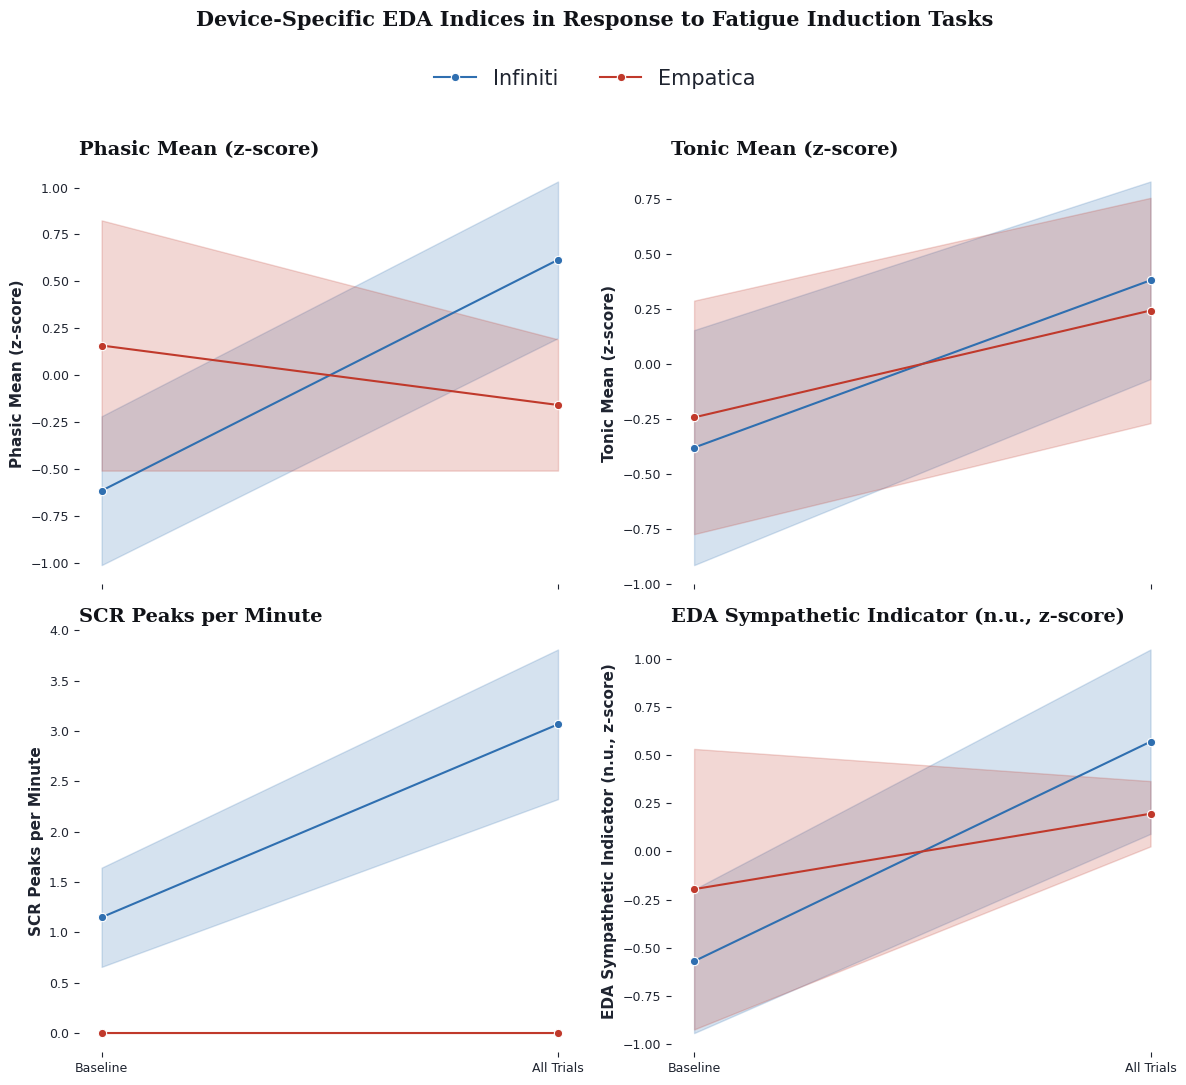

In [26]:
eda_interval_long = eda_interval_long[~eda_interval_long["participant_id"].isin(["OITC45", "OITC39"])]  # control group participants without CF
eda_interval_long = eda_interval_long[~eda_interval_long["segment"].isin(["Trial_1", "Trial_2", "Trial_3"])]  # only overall trial period, not individual trials
eda_interval_long["segment"] = eda_interval_long["segment"].replace({
    "All_Trials": "All Trials"
})

cols_to_normalize = ["EDA_SympatheticN", "Phasic_Mean", "Tonic_Mean"]

for col in cols_to_normalize:
    eda_interval_long[f"{col}_z"] = (
        eda_interval_long.groupby("device")[col]
        .transform(lambda x: (x - x.mean()) / x.std())
    )

eda_interval_long_pretty_names = eda_interval_long.rename(columns={
    "EDA_SympatheticN_z": "EDA Sympathetic Indicator (n.u., z-score)",
    "Phasic_Mean_z": "Phasic Mean (z-score)",
    "SCR_Peaks_per_minute": "SCR Peaks per Minute",
    "Tonic_Mean_z": "Tonic Mean (z-score)",
    "device": "Device",
    "segment": "Segment"
})

metrics = [
    "Phasic Mean (z-score)",
    "Tonic Mean (z-score)",
    "SCR Peaks per Minute",
    "EDA Sympathetic Indicator (n.u., z-score)",
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=False)
fig.patch.set_facecolor(THEME["figure_bg"])
axes_flat = axes.flatten()

n_devices = eda_interval_long_pretty_names["Device"].nunique()

for i, m in enumerate(metrics):
    ax = axes_flat[i]

    sns.lineplot(
        data=eda_interval_long_pretty_names,
        x="Segment",
        y=m,
        hue="Device",
        marker="o",
        errorbar="se",
        palette=DARK_PALETTE[:n_devices],
        markeredgecolor="white",
        markeredgewidth=0.8,
        legend=(i == 0),   # only draw one legend, reused via fig.legend below
        ax=ax,
    )

    style_dark_axes(ax, title=m, xlabel="", ylabel=m)

# pull the single legend out to the figure level and drop the per-axes one
handles, labels = axes_flat[0].get_legend_handles_labels()
axes_flat[0].get_legend().remove()
fig.legend(
    handles, labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.04),
    ncol=n_devices,
    frameon=False,
    labelcolor=THEME["text_color"],
    fontsize=15,
)

fig.suptitle(
    "Device-Specific EDA Indices in Response to Fatigue Induction Tasks",
    fontsize=15, fontweight="bold", family="serif", y=1.08, color=THEME["title_color"]
)

fig.tight_layout()
plt.savefig("Figure_X_Interactions.png", dpi=600, bbox_inches="tight")

In [27]:
eda_interval_long["segment"] = pd.Categorical(
    eda_interval_long["segment"],
    categories=["Baseline", "All Trials"]
)

model = smf.mixedlm(
    "SCR_Peaks_per_minute ~ segment * device",
    data=eda_interval_long,
    groups=eda_interval_long["participant_id"]
)

result = model.fit()
print(result.summary())

                       Mixed Linear Model Regression Results
Model:                   MixedLM      Dependent Variable:      SCR_Peaks_per_minute
No. Observations:        16           Method:                  REML                
No. Groups:              4            Scale:                   0.7935              
Min. group size:         4            Log-Likelihood:          -18.4173            
Max. group size:         4            Converged:               Yes                 
Mean group size:         4.0                                                       
-----------------------------------------------------------------------------------
                                         Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------------
Intercept                                -0.000    0.446 -0.000 1.000 -0.873  0.873
segment[T.All Trials]                     0.000    0.630  0.000 1.000 -1.235  1.235
device[T.Infini

c:\Conda\envs\Device_Comparison_PyEnv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Conda\envs\Device_Comparison_PyEnv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
c:\Conda\envs\Device_Comparison_PyEnv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [28]:
model = smf.mixedlm(
    "EDA_SympatheticN_z ~ segment * device",
    data=eda_interval_long,
    groups=eda_interval_long["participant_id"]
)

result = model.fit()
print(result.summary())

                       Mixed Linear Model Regression Results
Model:                   MixedLM       Dependent Variable:       EDA_SympatheticN_z
No. Observations:        16            Method:                   REML              
No. Groups:              4             Scale:                    0.9251            
Min. group size:         4             Log-Likelihood:           -19.3327          
Max. group size:         4             Converged:                Yes               
Mean group size:         4.0                                                       
-----------------------------------------------------------------------------------
                                         Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------------
Intercept                                -0.196    0.481 -0.407 0.684 -1.138  0.747
segment[T.All Trials]                     0.391    0.680  0.575 0.565 -0.942  1.724
device[T.Infini

c:\Conda\envs\Device_Comparison_PyEnv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
c:\Conda\envs\Device_Comparison_PyEnv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Conda\envs\Device_Comparison_PyEnv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


In [29]:
model = smf.mixedlm(
    "Phasic_Mean_z ~ segment * device",
    data=eda_interval_long,
    groups=eda_interval_long["participant_id"]
)

result = model.fit()
print(result.summary())

                       Mixed Linear Model Regression Results
Model:                    MixedLM         Dependent Variable:         Phasic_Mean_z
No. Observations:         16              Method:                     REML         
No. Groups:               4               Scale:                      0.2844       
Min. group size:          4               Log-Likelihood:             -15.6523     
Max. group size:          4               Converged:                  Yes          
Mean group size:          4.0                                                      
-----------------------------------------------------------------------------------
                                         Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------------
Intercept                                 0.158    0.474  0.334 0.738 -0.770  1.087
segment[T.All Trials]                    -0.317    0.377 -0.840 0.401 -1.056  0.422
device[T.Infini

In [30]:
model = smf.mixedlm(
    "Tonic_Mean_z ~ segment * device",
    data=eda_interval_long,
    groups=eda_interval_long["participant_id"]
)

result = model.fit()
print(result.summary())

                       Mixed Linear Model Regression Results
Model:                     MixedLM         Dependent Variable:         Tonic_Mean_z
No. Observations:          16              Method:                     REML        
No. Groups:                4               Scale:                      0.6643      
Min. group size:           4               Log-Likelihood:             -19.0937    
Max. group size:           4               Converged:                  Yes         
Mean group size:           4.0                                                     
-----------------------------------------------------------------------------------
                                         Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------------
Intercept                                -0.243    0.508 -0.479 0.632 -1.238  0.752
segment[T.All Trials]                     0.486    0.576  0.843 0.399 -0.644  1.615
device[T.Infini